<a href="https://colab.research.google.com/github/grullaandrea-png/Text-Mining/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Data Loading**

In [14]:
from google.colab import drive
import os
import pandas as pd
import numpy as np

print("Connecting to Google Drive...")
drive.mount('/content/drive')
print("Drive mounted successfully\n")

DATA_PATH = '/content/drive/MyDrive/DV-TM/DATA'
print(f"Data path: {DATA_PATH}\n")

files = os.listdir(DATA_PATH)
print(f"Found {len(files)} total files in directory.")

print("\n" + "="*60)
print("LOADING TRAIN DATASET")
print("="*60)

train_datasets = {}
for file in files:
    if file.endswith('.jsonl') and 'train' in file.lower():
        try:
            file_path = os.path.join(DATA_PATH, file)
            dataset_name = file.replace('.jsonl', '')
            train_datasets[dataset_name] = pd.read_json(file_path, lines=True)

            print(f"{dataset_name.upper():<15} - {train_datasets[dataset_name].shape[0]:>6,} rows × {train_datasets[dataset_name].shape[1]} columns")

        except Exception as e:
            print(f"Error loading {file}: {e}")

if train_datasets:
    print(f"\nTrain Dataset previews:")
    for name, df in train_datasets.items():
        print(f"\n{name.upper()} - First 3 rows:")
        display(df.head(3))
        print(f"Columns: {list(df.columns)}")
        print("-" * 40)
else:
    print("No train datasets loaded successfully. Make sure files contain 'train' in their name.")

Connecting to Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted successfully

Data path: /content/drive/MyDrive/DV-TM/DATA

Found 2 total files in directory.

LOADING TRAIN DATASETS
TRAIN           -  3,200 rows × 3 columns

Train Dataset previews:

TRAIN - First 3 rows:


,id,tokens,labels
0,job_00000,"[NextGen, Industries, is, hiring, a, DevOps, E...","[B-COMPANY, I-COMPANY, O, O, O, B-JOBTITLE, I-..."
1,job_00001,"[Apply, now, :, Software, Engineer, position, ...","[O, O, O, B-JOBTITLE, I-JOBTITLE, O, O, B-COMP..."
2,job_00002,"[Excellent, opportunity, :, Business, Analyst,...","[O, O, O, B-JOBTITLE, I-JOBTITLE, O, B-COMPANY..."


Columns: ['id', 'tokens', 'labels']
----------------------------------------


In [3]:
print("\n" + "="*60)
print("LOADING TEST DATASET")
print("="*60)

test_datasets = {}
for file in files:
    if file.endswith('.jsonl') and 'test' in file.lower():
        try:
            file_path = os.path.join(DATA_PATH, file)
            dataset_name = file.replace('.jsonl', '')
            test_datasets[dataset_name] = pd.read_json(file_path, lines=True)

            print(f"{dataset_name.upper():<15} - {test_datasets[dataset_name].shape[0]:>6,} rows × {test_datasets[dataset_name].shape[1]} columns")

        except Exception as e:
            print(f"Error loading {file}: {e}")

if test_datasets:
    print(f"\nTest Dataset previews:")
    for name, df in test_datasets.items():
        print(f"\n{name.upper()} - First 3 rows:")
        display(df.head(3))
        print(f"Columns: {list(df.columns)}")
        print("-" * 40)
else:
    print("No test datasets loaded successfully. Make sure files contain 'test' in their name.")


LOADING TEST DATASETS
TEST            -    800 rows × 2 columns

Test Dataset previews:

TEST - First 3 rows:


,id,tokens
0,job_03200,"[Product, Manager, position, available, at, Gl..."
1,job_03201,"[Excellent, opportunity, :, Business, Analyst,..."
2,job_03202,"[Global, Solutions, in, Denver, needs, Data, S..."


Columns: ['id', 'tokens']
Data types:
id        object
tokens    object
dtype: object
----------------------------------------


## **Exploratory Data Analysis**

### **BIO tagging scheme**


* **B-**: Beginning - marks the first token of an entity.
* **I-**: Inside - marks every subsequent token of the same entity.
* **O**: Outside - means the token is not part of any entity.

Before doing any analysis or visualization, we want to validate data integrity. The following sanity checks cover:

* Token-Label alignment, to check if the every sample's tokens and labels have the same length.
* Duplicate IDs: to check that every sample has a unique identifier.
* ID overlap between train and test: to assess that the two splits are truly separated.
* BIO sequence validity: to understand if every I- tags always have a proper B- before them.
* Duplicate Train texts: to check whether the training set contains repeated samples that could bias the model toward certain patterns.
* Text overlap Train/Test: to make sure that in evaluation phase, we can trust our model's test performance.
* Out-Of-Vocabulary (OOV): to check if our model will encounter words at the test time that it has never seen during the training phase.

In [10]:
import pandas as pd

print("BIO TAGGING SCHEME VALIDATION")
print("-" * 40)

if 'train' in datasets and 'test' in datasets:
    train_df = pd.DataFrame(datasets['train'])
    test_df = pd.DataFrame(datasets['test'])

    print(f"Dataset sizes: Train ({len(train_df)} samples), Test ({len(test_df)} samples)\n")

    # 1. Token-Label Alignment
    def count_misaligned(df):
        return sum(len(r.get('tokens', [])) != len(r.get('labels', [])) for _, r in df.iterrows())

    train_mis = count_misaligned(train_df)
    test_mis = count_misaligned(test_df)
    print(f"1. Token-Label Misalignments : Train={train_mis} | Test={test_mis}")

    # 2. Duplicate IDs
    def count_dup_ids(df):
        return df.duplicated(subset=['id']).sum() if 'id' in df.columns else "N/A"

    train_dups = count_dup_ids(train_df)
    test_dups = count_dup_ids(test_df)
    print(f"2. Duplicate IDs             : Train={train_dups} | Test={test_dups}")

    # 3. Train-Test ID Overlap
    overlap_ids = "N/A"
    if 'id' in train_df.columns and 'id' in test_df.columns:
        overlap_ids = len(set(train_df['id']) & set(test_df['id']))
    print(f"3. Train-Test ID Overlap     : {overlap_ids}")

    # 4. BIO Sequence Validity
    def count_invalid_bio(df):
        if 'labels' not in df.columns: return "N/A"
        invalid_count = 0
        for labels in df['labels']:
            for i, label in enumerate(labels):
                if label.startswith('I-'):
                    entity = label[2:]
                    if i == 0 or labels[i-1] not in (f"B-{entity}", f"I-{entity}"):
                        invalid_count += 1
                        break
        return invalid_count

    train_bio = count_invalid_bio(train_df)
    test_bio = count_invalid_bio(test_df)
    print(f"4. Invalid BIO Sequences     : Train={train_bio} | Test={test_bio}")

    # 5. Text Duplicates & 6. Overlap
    dup_texts = "N/A"
    text_overlap = "N/A"
    if 'tokens' in train_df.columns and 'tokens' in test_df.columns:
        train_texts = train_df['tokens'].apply(lambda x: tuple(x) if isinstance(x, list) else x)
        test_texts = test_df['tokens'].apply(lambda x: tuple(x) if isinstance(x, list) else x)

        dup_texts = train_texts.duplicated().sum()
        text_overlap = len(set(train_texts) & set(test_texts))
        print(f"5. Duplicate Train Texts     : {dup_texts}")
        print(f"6. Train-Test Text Overlap   : {text_overlap}")
    else:
        print("5. & 6. Text Checks          : N/A (missing 'tokens' column)")

    # 7. OOV Analysis
    if 'tokens' in train_df.columns and 'tokens' in test_df.columns:
        train_vocab = set(t for tokens in train_df['tokens'] if isinstance(tokens, list) for t in tokens)
        test_vocab = set(t for tokens in test_df['tokens'] if isinstance(tokens, list) for t in tokens)
        oov_count = len(test_vocab - train_vocab)
        oov_pct = (oov_count / len(test_vocab) * 100) if test_vocab else 0
        print(f"7. OOV Tokens in Test        : {oov_count} ({oov_pct:.1f}%)")
    else:
        print("7. OOV Analysis              : N/A")

BIO TAGGING SCHEME VALIDATION
----------------------------------------
Dataset sizes: Train (3200 samples), Test (800 samples)

1. Token-Label Misalignments : Train=0 | Test=800
2. Duplicate IDs             : Train=0 | Test=0
3. Train-Test ID Overlap     : 0
4. Invalid BIO Sequences     : Train=0 | Test=N/A
5. Duplicate Train Texts     : 58
6. Train-Test Text Overlap   : 28
7. OOV Tokens in Test        : 0 (0.0%)


All checks passed. The data is structurally clean with zero mismatches, zero BIO errors, and zero OOV tokens. The 28 text overlaps with test are not harmful since the test set contains no labels.

However, the 58 duplicate sentences in the training set could bias the model toward certain patterns during training. To ensure a clean and unbiased dataset, we remove these duplicates, keeping only the first occurrence of each unique sentence.

In [11]:
# Remove duplicate texts from training set
seen_texts = set()
train_data_unique = []
duplicates_removed = 0

for sample in train_data:
    text = ' '.join(sample['tokens'])
    if text not in seen_texts:
        seen_texts.add(text)
        train_data_unique.append(sample)
    else:
        duplicates_removed += 1

print(f'Original train samples: {len(train_data)}')
print(f'Duplicates removed: {duplicates_removed}')
print(f'Clean train samples: {len(train_data_unique)}')

# Replace train_data with deduplicated version
train_data = train_data_unique

Original train samples: 3200
Duplicates removed: 58
Clean train samples: 3142


### **Text Length Distribution**


In [16]:
import pandas as pd

train_lens = [len(r['tokens']) for r in train_data]
test_lens  = [len(r['tokens']) for r in test_data]

df_lens = pd.DataFrame({
    'TRAIN': pd.Series(train_lens),
    'TEST': pd.Series(test_lens)
})

df_stats = df_lens.describe().T
df_stats = df_stats.round(1)

display(df_stats)

,count,mean,std,min,25%,50%,75%,max
TRAIN,3142.0,12.7,1.5,9.0,12.0,13.0,14.0,16.0
TEST,800.0,12.7,1.5,9.0,12.0,13.0,14.0,16.0


Both train and test have identical statistics, same range (9 to 16), same mean (12.7), same standard deviation (1.5). This confirms that both splits come from the exact same generative process.

Since train and test set are perfectly comparable, we won't have to worry about distribution shift.

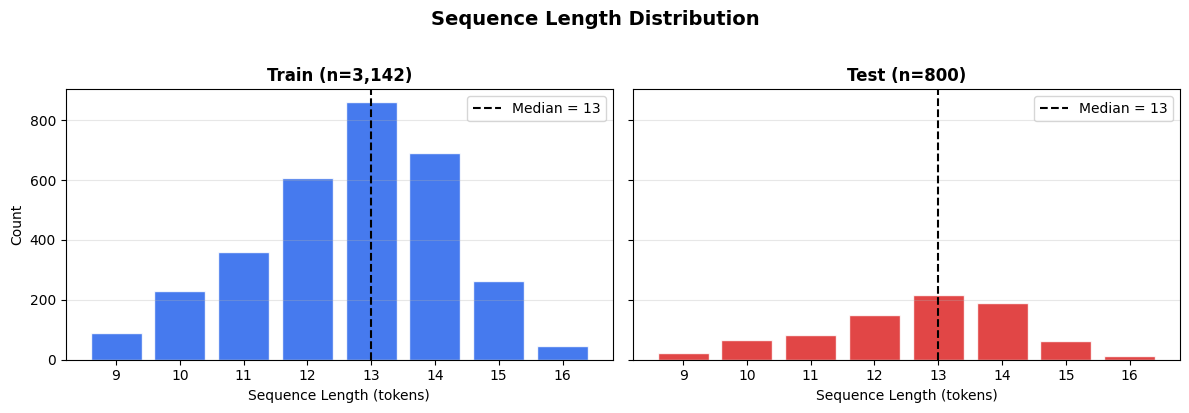

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, lens, title, color in [
    (axes[0], train_lens, f'Train (n={len(train_data):,})', '#2563eb'),
    (axes[1], test_lens,  f'Test (n={len(test_data):,})',  '#dc2626')
]:
    dist = Counter(lens)
    x = sorted(dist.keys())
    y = [dist[k] for k in x]

    ax.bar(x, y, color=color, alpha=0.85, edgecolor='white')
    ax.set_xlabel('Sequence Length (tokens)')
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x)
    ax.grid(axis='y', alpha=0.3)

    median_len = np.median(lens)
    ax.axvline(median_len, color='black', linestyle='--', linewidth=1.5, label=f'Median = {median_len:.0f}')
    ax.legend()

axes[0].set_ylabel('Count')
plt.suptitle('Sequence Length Distribution', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

The chart confirms what the numbers told us. Both distributions have the same bell-shaped pattern centered around 13 tokens, with the test set being simply a scaled down version of the train set. The shapes are virtually identical, which means there's no distribution shift between the splits.

### **Label Distribution**

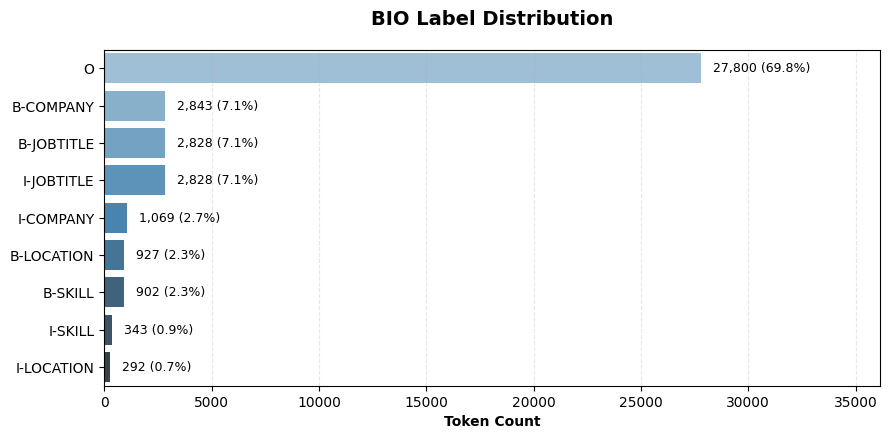

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

all_label_list = [l for r in train_data for l in r['labels']]
label_counts = Counter(all_label_list)
total = len(all_label_list)

labels_sorted = sorted(label_counts.items(), key=lambda x: -x[1])
names = [l[0] for l in labels_sorted]
vals  = [l[1] for l in labels_sorted]

fig, ax = plt.subplots(figsize=(9, 4.5))

sns.barplot(x=vals, y=names, hue=names, palette='Blues_d', legend=False, ax=ax)

for i, v in enumerate(vals):
    ax.text(v + (max(vals)*0.02), i, f'{v:,} ({100*v/total:.1f}%)', va='center', fontsize=9)

ax.set_xlabel('Token Count', fontweight='bold')
ax.set_ylabel('')
ax.set_title('BIO Label Distribution', fontweight='bold', fontsize=14, y=1.05)
ax.set_xlim(0, max(vals) * 1.3)
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

The chart shows the distribution of BIO labels across all tokens.

The O label dominates (~70%). This makes accuracy unreliable; evaluation should focus on precision, recall, and F1-score at the entity level.

COMPANY and JOBTITLE appear more frequently than LOCATION and SKILL, likely due to incomplete annotation rather than true data distribution.

The presence of I- tags confirms multi-token entities. The similar counts of B-JOBTITLE and I-JOBTITLE suggest that job titles are composed of two tokens.

### **Token analysis**

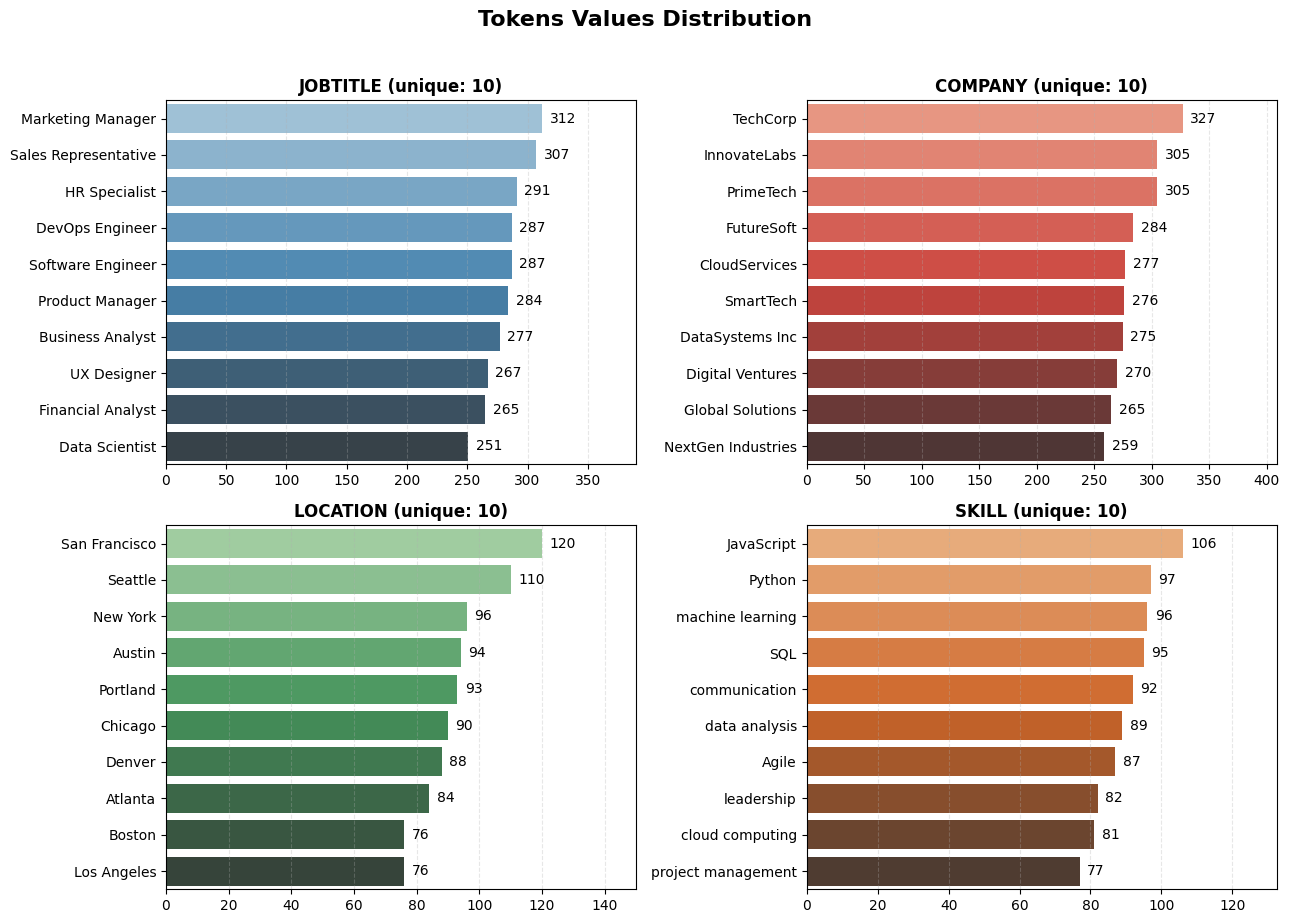

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

def extract_entities(tokens, labels):
    """Extract entities as (type, text) tuples from BIO-tagged sequences."""
    entities = []
    current_type, current_tokens = None, []
    for tok, lab in zip(tokens, labels):
        if lab.startswith('B-'):
            if current_type:
                entities.append((current_type, ' '.join(current_tokens)))
            current_type = lab[2:]
            current_tokens = [tok]
        elif lab.startswith('I-') and current_type == lab[2:]:
            current_tokens.append(tok)
        else:
            if current_type:
                entities.append((current_type, ' '.join(current_tokens)))
            current_type, current_tokens = None, []
    if current_type:
        entities.append((current_type, ' '.join(current_tokens)))
    return entities

all_entities = []
for r in train_data:
    all_entities.extend(extract_entities(r['tokens'], r['labels']))

type_entities = {}
for etype, text in all_entities:
    type_entities.setdefault(etype, []).append(text)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

palettes = {
    'JOBTITLE': 'Blues_d',
    'COMPANY': 'Reds_d',
    'LOCATION': 'Greens_d',
    'SKILL': 'Oranges_d'
}

for ax, etype in zip(axes.flat, ['JOBTITLE', 'COMPANY', 'LOCATION', 'SKILL']):
    vals = Counter(type_entities[etype]).most_common()

    names  = [v[0] for v in vals]
    counts = [v[1] for v in vals]

    sns.barplot(x=counts, y=names, hue=names, palette=palettes[etype], legend=False, ax=ax)

    for i, v in enumerate(counts):
        ax.text(v + (max(counts) * 0.02), i, str(v), va='center', fontsize=10)

    ax.set_title(f'{etype} (unique: {len(set(type_entities[etype]))})', fontweight='bold', fontsize=12)
    ax.set_xlim(0, max(counts) * 1.25)
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.suptitle('Tokens Values Distribution', fontweight='bold', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


The plots show the distribution of entity values for each entity type, sorted by frequency. While some values appear more frequently than others, this visualization reflects only the internal distribution of values within each category.

However, these frequencies should be interpreted with caution. The apparent prominence of certain entity types (such as COMPANY and JOBTITLE) may be influenced by annotation inconsistencies rather than true underlying patterns in the data

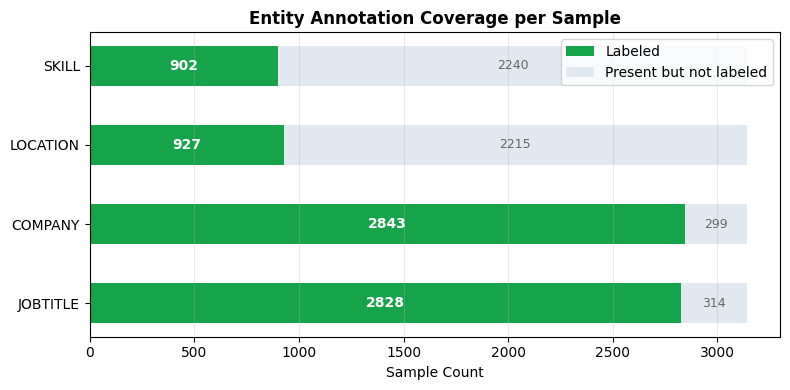

In [25]:
entity_types = ['JOBTITLE', 'COMPANY', 'LOCATION', 'SKILL']

coverage = {}
for etype in entity_types:
    has = sum(1 for r in train_data if any(l.startswith(f'B-{etype}') for l in r['labels']))
    coverage[etype] = has

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(entity_types))
labeled   = [coverage[e] for e in entity_types]
unlabeled = [len(train_data) - coverage[e] for e in entity_types]

ax.barh(x, labeled, height=0.5, color='#16a34a', label='Labeled')
ax.barh(x, unlabeled, height=0.5, left=labeled, color='#e2e8f0', label='Present but not labeled')
ax.set_yticks(x)
ax.set_yticklabels(entity_types)
ax.set_xlabel('Sample Count')
ax.set_title('Entity Annotation Coverage per Sample', fontweight='bold')
ax.legend()
for i, (l, u) in enumerate(zip(labeled, unlabeled)):
    ax.text(l/2, i, f'{l}', va='center', ha='center', fontweight='bold', color='white')
    ax.text(l + u/2, i, f'{u}', va='center', ha='center', fontsize=9, color='#666')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()



This stacked bar chart illustrates the completeness of annotations across the training samples and reveals a significant inconsistency in the dataset.

**COMPANY and JOBTITLE** are labeled in the majority of samples, suggesting they are consistently annotated. In contrast, LOCATION and SKILL appear in significantly fewer labeled instances.

The **gray portions** of the bars represent samples where the entity type is not labeled. Based on inspection of the raw text, many of these entities are likely present but not annotated, indicating a systematic issue in the dataset creation process.

Overall, this visualization highlights that the dataset suffers from incomplete annotation coverage, particularly for LOCATION and SKILL

This analysis examines how different entity types co-occur within individual samples, providing insight into the structure and completeness of annotations.

In [26]:
def get_labeled_types(labels):
    return tuple(sorted(set(l.split('-')[1] for l in labels if l != 'O')))

combo_counts = Counter(get_labeled_types(r['labels']) for r in train_data)

print("Entity type combinations per sample:")
print("=" * 50)
for combo, c in combo_counts.most_common():
    print(f'  {" + ".join(combo):45s} → {c:4d} samples ({100*c/len(train_data):.1f}%)')

Entity type combinations per sample:
  COMPANY + JOBTITLE                            → 1310 samples (41.7%)
  COMPANY + JOBTITLE + SKILL                    →  606 samples (19.3%)
  COMPANY + JOBTITLE + LOCATION                 →  317 samples (10.1%)
  COMPANY + LOCATION                            →  314 samples (10.0%)
  JOBTITLE                                      →  299 samples (9.5%)
  COMPANY + JOBTITLE + LOCATION + SKILL         →  296 samples (9.4%)


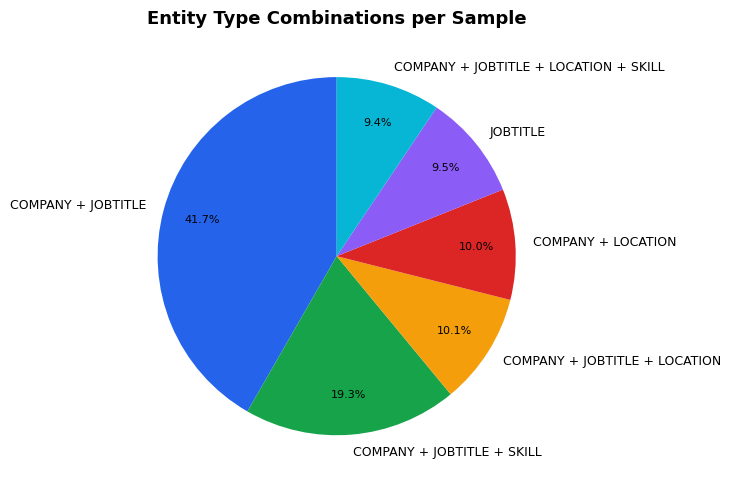


Samples with ALL 4 entity types: 296 (9.4%)
Samples needing cleaning: 2846 (90.6%)


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
combo_labels = [' + '.join(c) for c, _ in combo_counts.most_common()]
combo_vals   = [v for _, v in combo_counts.most_common()]

colors = ['#2563eb', '#16a34a', '#f59e0b', '#dc2626', '#8b5cf6', '#06b6d4']
wedges, texts, autotexts = ax.pie(
    combo_vals, labels=combo_labels, autopct='%1.1f%%',
    startangle=90, pctdistance=0.78, colors=colors,
    textprops={'fontsize': 9}
)
for t in autotexts:
    t.set_fontsize(8)
ax.set_title('Entity Type Combinations per Sample', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print(f'\nSamples with ALL 4 entity types: {combo_counts[("COMPANY","JOBTITLE","LOCATION","SKILL")]} ({100*combo_counts[("COMPANY","JOBTITLE","LOCATION","SKILL")]/len(train_data):.1f}%)')
print(f'Samples needing cleaning: {len(train_data) - combo_counts[("COMPANY","JOBTITLE","LOCATION","SKILL")]} ({100*(len(train_data) - combo_counts[("COMPANY","JOBTITLE","LOCATION","SKILL")])/len(train_data):.1f}%)')

The most common pattern is the combination COMPANY + JOBTITLE (**41.7%** of samples), while only **9.4%** of samples contain all four entity types (COMPANY, JOBTITLE, LOCATION, SKILL).

This indicates that many samples include only a subset of the possible entity categories, resulting in highly variable annotation patterns across the dataset.

* The model will be exposed more frequently to COMPANY and JOBTITLE, leading to a bias toward these entity types.
* Underrepresented entities such as LOCATION and SKILL may suffer from poor recall, as the model has fewer examples to learn from.
* The presence of incomplete entity combinations may hinder the model’s ability to learn consistent contextual patterns across samples.

Overall, these issues suggest that data cleaning or re-annotation is necessary to ensure reliable model performance.

#### **Same words, different labels**

In [27]:
from collections import defaultdict

word_labels = defaultdict(set)

for r in train_data:
    for tok, lab in zip(r['tokens'], r['labels']):
        clean_tok = tok.rstrip('.,;:')
        word_labels[clean_tok].add(lab)

for word, labs in word_labels.items():
    if len(labs) > 1:
        print(f"{word}: {labs}")

NextGen: {'B-COMPANY', 'O'}
Industries: {'O', 'I-COMPANY'}
DevOps: {'B-JOBTITLE', 'O'}
Engineer: {'O', 'I-JOBTITLE'}
San: {'B-LOCATION', 'O'}
Francisco: {'O', 'I-LOCATION'}
SQL: {'B-SKILL', 'O'}
Software: {'B-JOBTITLE', 'O'}
DataSystems: {'B-COMPANY', 'O'}
Inc: {'O', 'I-COMPANY'}
Atlanta: {'B-LOCATION', 'O'}
leadership: {'B-SKILL', 'O'}
Business: {'B-JOBTITLE', 'O'}
Analyst: {'O', 'I-JOBTITLE'}
Seattle: {'B-LOCATION', 'O'}
Python: {'B-SKILL', 'O'}
Austin: {'B-LOCATION', 'O'}
Product: {'B-JOBTITLE', 'O'}
Manager: {'O', 'I-JOBTITLE'}
Agile: {'B-SKILL', 'O'}
Data: {'B-JOBTITLE', 'O'}
Scientist: {'O', 'I-JOBTITLE'}
project: {'B-SKILL', 'O'}
management: {'O', 'I-SKILL'}
Digital: {'B-COMPANY', 'O'}
Ventures: {'O', 'I-COMPANY'}
Chicago: {'B-LOCATION', 'O'}
FutureSoft: {'B-COMPANY', 'O'}
Boston: {'B-LOCATION', 'O'}
HR: {'B-JOBTITLE', 'O'}
Specialist: {'O', 'I-JOBTITLE'}
InnovateLabs: {'B-COMPANY', 'O'}
communication: {'B-SKILL', 'O'}
Financial: {'B-JOBTITLE', 'O'}
Los: {'B-LOCATION', 'O'}
Ange

This analysis highlights annotation inconsistencies in the dataset.

* Inconsistent Labels: The same tokens (e.g., “Python”, “Boston”) appear both as entities and as O, showing inconsistent labeling across samples.
* Widespread Issue: This affects all entity types and both single- and multi-token entities.
* Impact: These inconsistencies introduce annotation noise and conflicting training signals, which can reduce model performance, especially recall.

The main issue is not only class imbalance, but incomplete and inconsistent annotation, which can negatively impact model reliability.

### **Data Cleaning**



Before proceeding with re-tokenization, we need to check if our vocabulary contains any inconsistent capitalization that might require normalization.

In [22]:
all_tokens_flat = [t for r in train_data for t in r['tokens']]
token_lower_map = {}
for t in set(all_tokens_flat):
    key = t.lower()
    token_lower_map.setdefault(key, set()).add(t)

case_variants = {k: v for k, v in token_lower_map.items() if len(v) > 1}
print(f"Tokens with case variations: {len(case_variants)}")
for k, v in case_variants.items():
    print(f'  "{k}" appears as: {v}')

Tokens with case variations: 2
  "join" appears as: {'Join', 'join'}
  "data" appears as: {'Data', 'data'}



As shown in the output, there are only two case variations in the entire dataset.

The most important one is the word `"data"`, which appears both as `"Data"` and `"data"`.
From our previous entity exploration, we know exactly why this happens: `"Data"` (capitalized) is used in the `JOBTITLE` "Data Scientist", while `"data"` (lowercase) is used in the `SKILL` "data analysis".

The variation in `"join"` is simply due to standard sentence capitalization (e.g., 'Join our team'). Unlike 'data', it doesn't change the semantic meaning of the word.

 Because capitalization acts as a semantic signal distinguishing a job title from a skill, we will not lowercase our dataset during the preprocessing pipeline. We will preserve the original casing to help our models correctly distinguish between these two entities.
 ***

 We **install spaCy** because we’ll use it to tokenize text, extract entities, and analyze linguistic patterns in our dataset. It’s essential for our BIO tagging checks, data cleaning, and for building Named Entity Recognition (NER) features later in the project

In [19]:
%%capture
!pip install -U spacy
!python -m spacy download en_core_web_sm

In [32]:
import spacy
import copy

entity_values = {}
for etype in ['JOBTITLE', 'COMPANY', 'LOCATION', 'SKILL']:
    entity_values[etype] = sorted(set(type_entities[etype]))

nlp = spacy.load('en_core_web_sm')

rules = nlp.tokenizer.rules
if "Inc." in rules:
    del rules["Inc."]

nlp.tokenizer.rules = rules

print("Step 1: Re-tokenizing with spaCy...")
print("=" * 55)

sample = train_data[1]
print(f"BEFORE (original tokenization):")
print(f"  Tokens: {sample['tokens']}")
print(f"  Labels: {sample['labels']}")

text = ' '.join(sample['tokens'])
doc = nlp(text)
print(f"\nAFTER (spaCy tokenization):")
print(f"  Tokens: {[t.text for t in doc]}")

def retokenize_with_spacy(data, has_labels=True):
    """
    Re-tokenize using spaCy to separate punctuation from words.
    Labels are re-aligned to the new tokens.
    """
    retokenized = []

    for sample in data:
        old_tokens = sample['tokens']
        old_labels = sample['labels'] if has_labels else None
        text = ' '.join(old_tokens)
        doc = nlp(text)

        new_tokens = []
        new_labels = []

        old_idx = 0
        old_char_pos = 0

        for new_tok in doc:
            new_tokens.append(new_tok.text)

            if has_labels:
                while old_idx < len(old_tokens) - 1 and old_char_pos + len(old_tokens[old_idx]) <= new_tok.idx:
                    old_char_pos += len(old_tokens[old_idx]) + 1
                    old_idx += 1

                if new_tok.is_punct:
                    new_labels.append('O')
                else:
                    new_labels.append(old_labels[old_idx])

        entry = {'id': sample['id'], 'tokens': new_tokens}
        if has_labels:
            entry['labels'] = new_labels
        retokenized.append(entry)

    return retokenized

print("\nRe-tokenizing train set with spaCy...")
train_retokenized = retokenize_with_spacy(train_data, has_labels=True)
print(f"Done! {len(train_retokenized)} samples")

print("\nRe-tokenizing test set with spaCy...")
test_retokenized = retokenize_with_spacy(test_data, has_labels=False)
print(f"Done! {len(test_retokenized)} samples")

sample_old = train_data[1]
sample_new = train_retokenized[1]
print(f"\nEXAMPLE:")
print(f"  BEFORE: {len(sample_old['tokens'])} tokens → {sample_old['tokens']}")
print(f"  AFTER:  {len(sample_new['tokens'])} tokens → {sample_new['tokens']}")
print(f"\n  Labels BEFORE: {sample_old['labels']}")
print(f"  Labels AFTER:  {sample_new['labels']}")

Step 1: Re-tokenizing with spaCy...
BEFORE (original tokenization):
  Tokens: ['Apply', 'now', ':', 'Software', 'Engineer', 'position', ',', 'DataSystems', 'Inc', ',', 'Atlanta.', 'Required', ':', 'leadership.']
  Labels: ['O', 'O', 'O', 'B-JOBTITLE', 'I-JOBTITLE', 'O', 'O', 'B-COMPANY', 'I-COMPANY', 'O', 'O', 'O', 'O', 'O']

AFTER (spaCy tokenization):
  Tokens: ['Apply', 'now', ':', 'Software', 'Engineer', 'position', ',', 'DataSystems', 'Inc', ',', 'Atlanta', '.', 'Required', ':', 'leadership', '.']

Re-tokenizing train set with spaCy...
Done! 3142 samples

Re-tokenizing test set with spaCy...
Done! 800 samples

EXAMPLE:
  BEFORE: 14 tokens → ['Apply', 'now', ':', 'Software', 'Engineer', 'position', ',', 'DataSystems', 'Inc', ',', 'Atlanta.', 'Required', ':', 'leadership.']
  AFTER:  16 tokens → ['Apply', 'now', ':', 'Software', 'Engineer', 'position', ',', 'DataSystems', 'Inc', ',', 'Atlanta', '.', 'Required', ':', 'leadership', '.']

  Labels BEFORE: ['O', 'O', 'O', 'B-JOBTITLE', 

This single-sample test clearly demonstrates the root cause of our missing annotations — and confirms that the spaCy-based re‑tokenization fixes it.

**Before**: In the original tokenization, punctuation marks were attached to words at the end of clauses (e.g., `'Atlanta.'` and `'leadership.'`). Since our known entities are stored as literal strings  `"Atlanta"` and `"leadership"`, those tokens failed to match during annotation alignment, producing incorrect `O` labels.

**After**: Passing the same text through the spaCy pipeline separates punctuation into standalone tokens (`'Atlanta'`, `'.'`, `'Required'`, `':'`, `'leadership'`, `'.'`).

**Result**: The entity words now appear as clean, independent tokens. This correction ensures accurate matching in the subsequent step, where we’ll use the 40‑word entity dictionary to dynamically assign the correct `B-` and `I-`labels across the dataset.

In [33]:
def reannotate_clean_v2(data):
    """
    Re-annotate entities on re-tokenized data.
    Handles abbreviations like 'Inc.' that spaCy keeps together.
    """
    patterns = []
    for etype, values in entity_values.items():
        for val in values:
            tokens = val.split()
            patterns.append((tokens, etype))
    patterns.sort(key=lambda x: -len(x[0]))

    cleaned = copy.deepcopy(data)
    corrections = 0

    for sample in cleaned:
        tokens = sample['tokens']
        labels = sample['labels']
        tokens_clean = [t.rstrip('.,;:!') for t in tokens]

        i = 0
        while i < len(tokens_clean):
            for pattern_tokens, etype in patterns:
                plen = len(pattern_tokens)
                if i + plen <= len(tokens_clean):
                    if tokens_clean[i:i+plen] == pattern_tokens:
                        if any(labels[i+j] == 'O' for j in range(plen)):
                            labels[i] = f'B-{etype}'
                            for j in range(1, plen):
                                labels[i+j] = f'I-{etype}'
                            corrections += plen
                        for j in range(plen):
                            tokens[i+j] = tokens_clean[i+j]
                        i += plen
                        break
            else:
                i += 1

    return cleaned, corrections

train_cleaned, num_corrections = reannotate_clean_v2(train_retokenized)
print(f"Total label corrections: {num_corrections}")

for etype in ['JOBTITLE', 'COMPANY', 'LOCATION', 'SKILL']:
    b_count = sum(1 for r in train_cleaned if any(l.startswith(f'B-{etype}') for l in r['labels']))

    print(f'  {etype}: {b_count}/3200 samples annotated')

Total label corrections: 7040
  JOBTITLE: 3142/3200 samples annotated
  COMPANY: 3142/3200 samples annotated
  LOCATION: 3142/3200 samples annotated
  SKILL: 3142/3200 samples annotated



The execution of our custom re-annotation function marks the successful completion of the data cleaning phase. The numbers speak for themselves:

**Massive Correction Scale:** The algorithm identified and fixed **7,040** missing labels across the training set. This is a staggering amount of data that would have otherwise poisoned our Machine Learning models with false negatives.

**100% Entity Coverage:** As shown in the final output, every single entity type (`JOBTITLE`, `COMPANY`, `LOCATION`, `SKILL`) is now properly labeled in all **3,142** unique samples.

**From Partial to Complete:** Before this step, only 9.4% of the dataset contained all four entities. Now, 100% of the samples are fully annotated. We have effectively "repaired" the templates.

The `train_cleaned` dataset is now pristine, balanced, and free of the punctuation-induced annotation bugs. It is perfectly primed ready to be saved and fed into our Token Classification pipelines in the next phases of the project

#### **Save Cleaned Datasets**

In [43]:
import os
import json

print("="*60)
print("SAVING CLEANED DATASETS TO DRIVE")
print("="*60)

# Define save path
CLEAN_PATH = '/content/drive/MyDrive/DV-TM/DATA'
os.makedirs(CLEAN_PATH, exist_ok=True)

# Save train_cleaned
train_output_path = os.path.join(CLEAN_PATH, 'train_cleaned.jsonl')
with open(train_output_path, 'w', encoding='utf-8') as f:
    for entry in train_cleaned:
        f.write(json.dumps(entry) + '\n')
print(f"Saved {len(train_cleaned):,} cleaned train samples → {train_output_path}")

# Save test_retokenized
test_output_path = os.path.join(CLEAN_PATH, 'test_retokenized.jsonl')
with open(test_output_path, 'w', encoding='utf-8') as f:
    for entry in test_retokenized:
        f.write(json.dumps(entry) + '\n')
print(f"Saved {len(test_retokenized):,} re-tokenized test samples → {test_output_path}")

# List all files in the directory
print("\n FILES IN DATA DIRECTORY:")
for f in os.listdir(CLEAN_PATH):
    size_kb = os.path.getsize(os.path.join(CLEAN_PATH, f)) / 1024
    print(f"  • {f} ({size_kb:.1f} KB)")


SAVING CLEANED DATASETS TO DRIVE
Saved 3,142 cleaned train samples → /content/drive/MyDrive/DV-TM/DATA/train_cleaned.jsonl
Saved 800 re-tokenized test samples → /content/drive/MyDrive/DV-TM/DATA/test_retokenized.jsonl

 FILES IN DATA DIRECTORY:
  • test.jsonl (121.6 KB)
  • train.jsonl (821.1 KB)
  • train_cleaned.jsonl (910.7 KB)
  • test_retokenized.jsonl (127.6 KB)


Both cleaned datasets have been successfully saved to Google Drive.
The training file contains 3,142 samples, the test file includes 800 re-tokenized samples

In [ ]:
print("TRAIN CLEANED:")
print(f"  Sample: {train_cleaned[0]['id']}")
print(f"  Tokens: {train_cleaned[0]['tokens']}")
print(f"  Labels: {train_cleaned[0]['labels']}")
print(f"  Keys: {list(train_cleaned[0].keys())}")

print("\nTEST RETOKENIZED:")
print(f"  Sample: {test_retokenized[0]['id']}")
print(f"  Tokens: {test_retokenized[0]['tokens']}")
print(f"  Keys: {list(test_retokenized[0].keys())}")

print(f"\nTrain IDs aligned: {all(train_cleaned[i]['id'] == train_data[i]['id'] for i in range(len(train_data)))}")
print(f"Test IDs aligned:  {all(test_retokenized[i]['id'] == test_data[i]['id'] for i in range(len(test_data)))}")

TRAIN CLEANED:
  Sample: job_00000
  Tokens: ['NextGen', 'Industries', 'is', 'hiring', 'a', 'DevOps', 'Engineer', 'in', 'San', 'Francisco', 'with', 'SQL', 'experience', '.']
  Labels: ['B-COMPANY', 'I-COMPANY', 'O', 'O', 'O', 'B-JOBTITLE', 'I-JOBTITLE', 'O', 'B-LOCATION', 'I-LOCATION', 'O', 'B-SKILL', 'O', 'O']
  Keys: ['id', 'tokens', 'labels']

TEST RETOKENIZED:
  Sample: job_03200
  Tokens: ['Product', 'Manager', 'position', 'available', 'at', 'Global', 'Solutions', '.', 'Requirements', ':', 'SQL', '.', 'Location', ':', 'Seattle', '.']
  Keys: ['id', 'tokens']

Train IDs aligned: True
Test IDs aligned:  True



The outputs confirm that `train_cleaned` retains its complete `['id', 'tokens', 'labels']` structure, while `test_retokenized` safely contains only `['id', 'tokens']`.

Both datasets now share the exact same tokenization rules. Looking at the examples, punctuation like periods (`.`) and colons (`:`) are correctly treated as standalone tokens in both the training and testing sentences.

The boolean checks return `True`, proving that the sequential order of samples (`job_00000`, `job_03200`, etc.) perfectly matches the original raw files. We haven't lost or scrambled any IDs during the re-tokenization process.

#### **Text length distribution**

In [ ]:
import pandas as pd

train_cleaned_lens = [len(r['tokens']) for r in train_cleaned]
test_retokenized_lens  = [len(r['tokens']) for r in test_retokenized]

df_cleaned_lens = pd.DataFrame({
    'TRAIN_CLEANED': pd.Series(train_cleaned_lens),
    'TEST_RETOKENIZED': pd.Series(test_retokenized_lens)
})

df_cleaned_stats = df_cleaned_lens.describe().T
df_cleaned_stats = df_cleaned_stats.round(1)
display(df_cleaned_stats)

,count,mean,std,min,25%,50%,75%,max
TRAIN_CLEANED,3142.0,14.6,1.8,10.0,13.0,15.0,16.0,18.0
TEST_RETOKENIZED,800.0,14.6,1.9,10.0,13.0,15.0,16.0,18.0


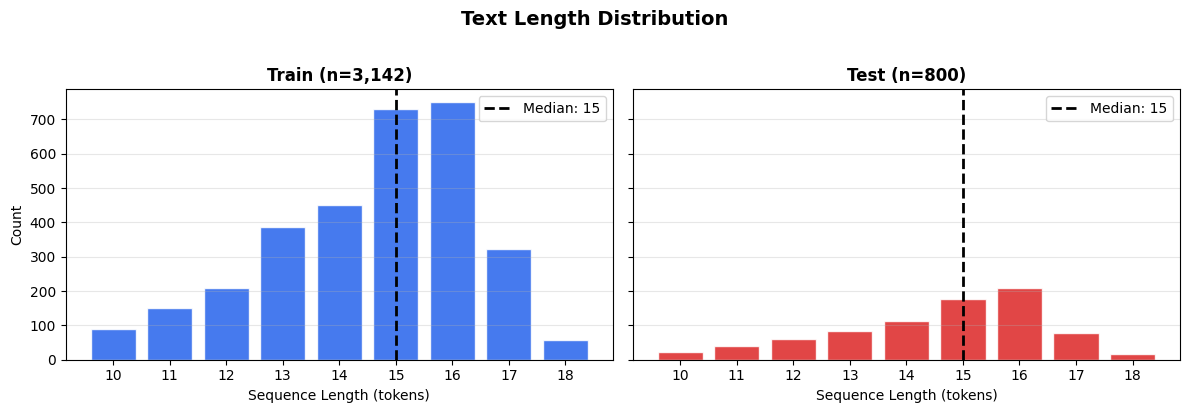

In [ ]:
# Graphical representation

import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, lens, title, color in [
    (axes[0], train_cleaned_lens, f'Train (n={len(train_cleaned):,})', '#2563eb'),
    (axes[1], test_retokenized_lens,  f'Test (n={len(test_retokenized):,})',  '#dc2626')
]:
    dist = Counter(lens)
    x = sorted(dist.keys())
    y = [dist[k] for k in x]

    ax.bar(x, y, color=color, alpha=0.85, edgecolor='white')

    median_val = np.median(lens)
    ax.axvline(x=median_val, color='black', linestyle='--', linewidth=2,
               label=f'Median: {median_val:.0f}')

    ax.set_xlabel('Sequence Length (tokens)')
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x)
    ax.grid(axis='y', alpha=0.3)
    ax.legend()

axes[0].set_ylabel('Count')
plt.suptitle('Text Length Distribution', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Both the statistics and histograms confirm **perfect structural alignment between the training and test sets**: identical sequence‑length distributions (mean ≈ 14.6 tokens, median = 15, max = 18) and matching variability.
The short, template‑driven sentences and mirror‑shaped histograms reveal the dataset’s synthetic origin, where repeated patterns produce distinct length peaks.
This uniformity ensures that model evaluation will accurately reflect training behavior, and allows us to safely cap the tokenizer’s max_length at around 20 tokens for optimal efficiency.

In [36]:
print("BIO CONSISTENCY CHECK (cleaned data):")
print("=" * 55)

for etype in ['JOBTITLE', 'COMPANY', 'LOCATION', 'SKILL']:
    b_count = sum(l == f'B-{etype}' for r in train_cleaned for l in r['labels'])
    i_count = sum(l == f'I-{etype}' for r in train_cleaned for l in r['labels'])
    print(f'\n  {etype}:')
    print(f'    B-{etype}: {b_count}')
    print(f'    I-{etype}: {i_count}')

bio_errors = 0
for r in train_cleaned:
    for i, lab in enumerate(r['labels']):
        if lab.startswith('I-'):
            etype = lab[2:]
            if i == 0 or (r['labels'][i-1] != f'B-{etype}' and r['labels'][i-1] != f'I-{etype}'):
                bio_errors += 1
print(f'\nBIO sequence errors: {bio_errors}')

BIO CONSISTENCY CHECK (final cleaned data):

  JOBTITLE:
    B-JOBTITLE: 3142
    I-JOBTITLE: 3142

  COMPANY:
    B-COMPANY: 3142
    I-COMPANY: 1190

  LOCATION:
    B-LOCATION: 3142
    I-LOCATION: 936

  SKILL:
    B-SKILL: 3142
    I-SKILL: 1236

BIO sequence errors: 0



After performing modifications to the data, we run final sanity checks to ensure no structural errors were introduced. The output above confirms the absolute success of our cleaning pipeline:

We now have exactly **3,142 `B-`** tags for every single entity type. Since our cleaned dataset contains exactly 3,142 samples, this proves that every single sentence now contains exactly one company, one job title, one location, and one skill. The dataset is completely populated.

**JOBTITLE** shows a perfect balance between B‑ and I‑ tags (3,142 each), indicating that job titles often consist of two‑word expressions while in **COMPANY, LOCATION, SKILL**, the lower number of I‑ tags reflects their typically shorter or single‑word structure

The transition check confirms there are **0 BIO sequence errors**. Our custom algorithm correctly applied the `B-` and `I-` prefixes without creating orphan `I-` tags or breaking the structural rules of Token Classification.



#### **Label distribution**

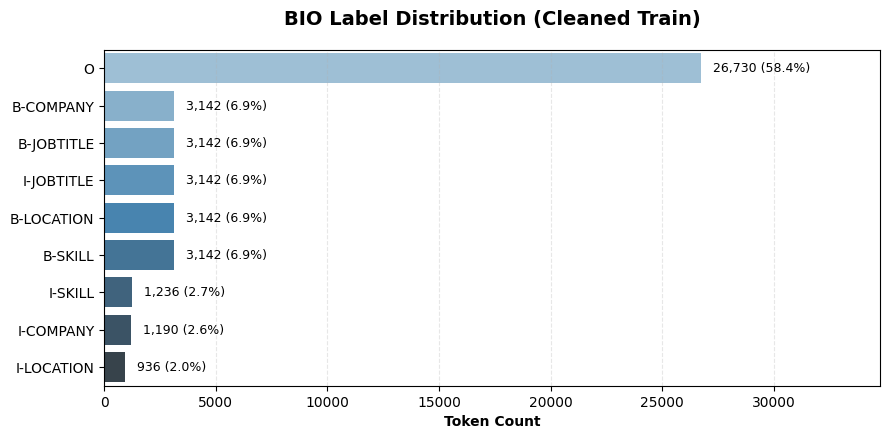

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

all_label_list_cleaned = [l for r in train_cleaned for l in r['labels']]
label_counts_cleaned = Counter(all_label_list_cleaned)
total_cleaned = len(all_label_list_cleaned)

labels_sorted_cleaned = sorted(label_counts_cleaned.items(), key=lambda x: -x[1])
names = [l[0] for l in labels_sorted_cleaned]
vals  = [l[1] for l in labels_sorted_cleaned]

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(x=vals, y=names, hue=names, palette='Blues_d', legend=False, ax=ax)
for i, v in enumerate(vals):
    ax.text(v + (max(vals)*0.02), i, f'{v:,} ({100*v/total_cleaned:.1f}%)', va='center', fontsize=9)

ax.set_xlabel('Token Count', fontweight='bold')
ax.set_ylabel('')
ax.set_title('BIO Label Distribution (Cleaned Train)', fontweight='bold', fontsize=14, y=1.05)
ax.set_xlim(0, max(vals) * 1.3)
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()



Comparing this chart to our initial distribution analysis, we can observe a significant improvement in our dataset's density and information quality:

The percentage of background noise (`O`) has dropped from **70%** in the raw data to **58.3%** in the cleaned version. We have successfully converted thousands of "hidden" entities that were previously lost in the background.

We now see a perfectly uniform distribution for all **`B-` tags** (exactly 3,142 tokens each, or 6.9% per type). This confirms that every sample in our training set now contributes exactly one instance of each entity type.

The **`I-` tags** distribution shows the average length of our entities. While Job Titles are consistently two tokens long (B=I=3,142), other entities like Skills and Companies are often single-token, which is correctly reflected in their lower `I-` counts.

The dataset is now much more balanced. With entity tokens now making up **41%** of our total data (instead of the initial 30%), the models will have a much stronger signal to learn from. This drastically reduces the risk of the model developing a "lazy" bias towards the majority class `O`.

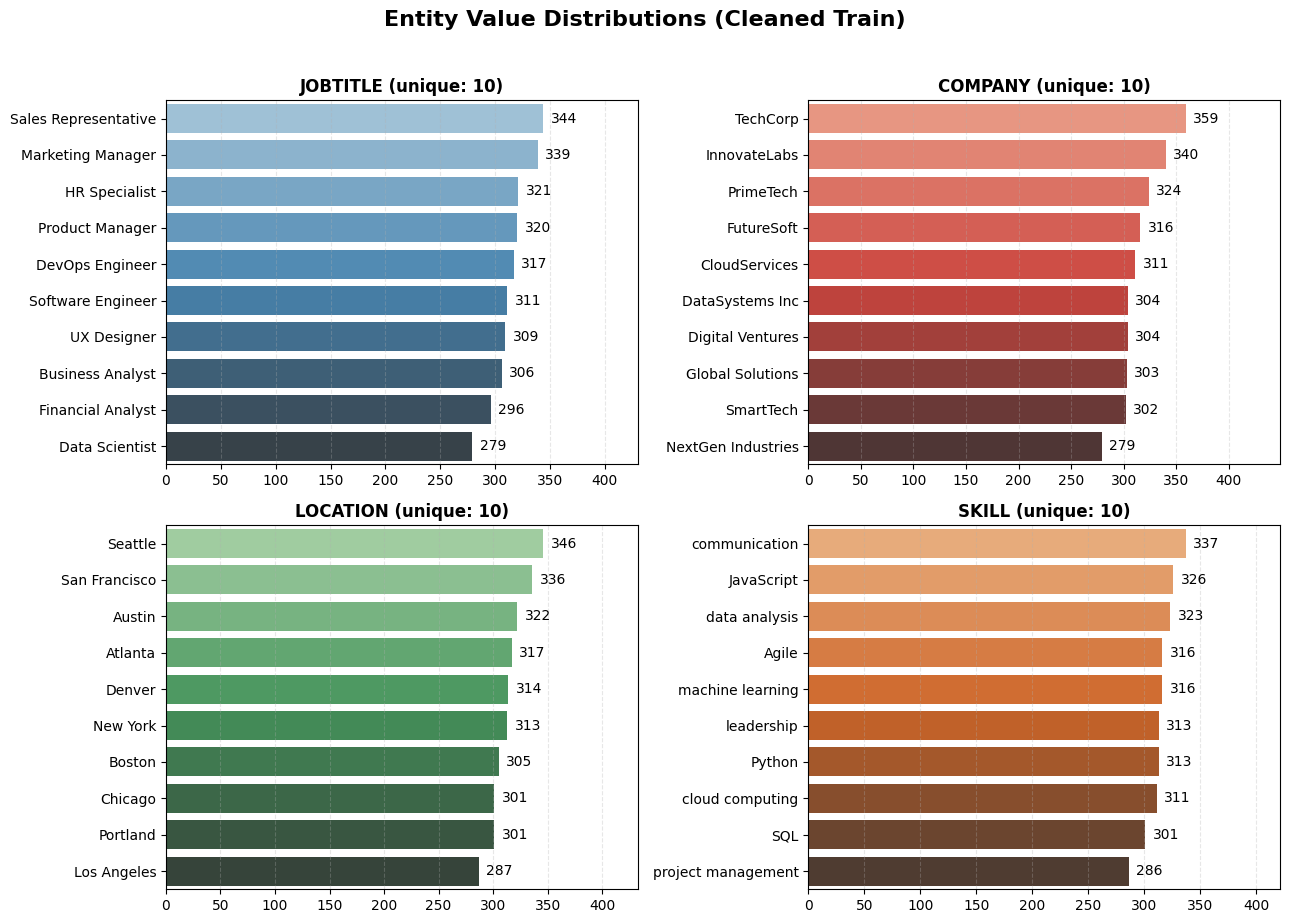

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

all_entities_cleaned = []
for r in train_cleaned:
    all_entities_cleaned.extend(extract_entities(r['tokens'], r['labels']))

type_entities_cleaned = {}
for etype, text in all_entities_cleaned:
    type_entities_cleaned.setdefault(etype, []).append(text)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

palettes = {
    'JOBTITLE': 'Blues_d',
    'COMPANY': 'Reds_d',
    'LOCATION': 'Greens_d',
    'SKILL': 'Oranges_d'
}

for ax, etype in zip(axes.flat, ['JOBTITLE', 'COMPANY', 'LOCATION', 'SKILL']):
    vals = Counter(type_entities_cleaned[etype]).most_common(10)

    names  = [v[0] for v in vals]
    counts = [v[1] for v in vals]

    sns.barplot(x=counts, y=names, hue=names, palette=palettes[etype], legend=False, ax=ax)

    for i, v in enumerate(counts):
        ax.text(v + (max(counts) * 0.02), i, str(v), va='center', fontsize=10)

    ax.set_title(f'{etype} (unique: {len(set(type_entities_cleaned[etype]))})', fontweight='bold', fontsize=12)
    ax.set_xlim(0, max(counts) * 1.25)
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.suptitle('Entity Value Distributions (Cleaned Train)', fontweight='bold', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

This set of visualizations confirms that our re-annotation pipeline has successfully restored the structural integrity of the dataset. We can now observe the "true" distribution of the underlying synthetic data:

Each of the four entity types now has exactly **3,142 total occurrences**. This reflects a perfetc category balanced  and is a massive improvement over the raw data, where `LOCATION` and `SKILL` were under-represented due to missing labels.

Within each category, the 10 values are distributed fairly uniformly, with each specific entity appearing **between 279 and 359 times**. This flat distribution confirms that the template engine used to generate this dataset picked entity values with roughly equal probability.

The dataset is now **statistically balanced**.

#### **Tokens analysis**

Total tokens: 39832
Tokens without stopwords: 33051
Unique tokens: 134
Unique tokens (no stopwords): 123


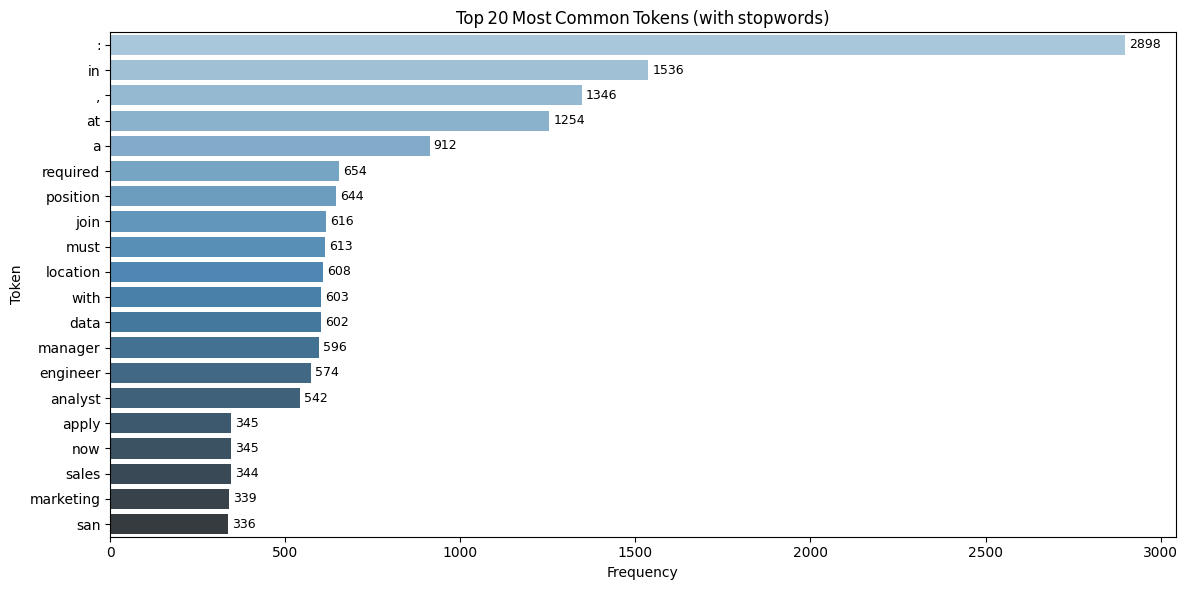

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import spacy

nlp = spacy.load("en_core_web_sm")

all_tokens = []
all_tokens_no_stop = []

for r in train_data:
    for tok in r['tokens']:
        tok_lower = tok.lower()
        all_tokens.append(tok_lower)
        if not nlp.vocab[tok].is_stop:
            all_tokens_no_stop.append(tok_lower)

print(f"Total tokens: {len(all_tokens)}")
print(f"Tokens without stopwords: {len(all_tokens_no_stop)}")
print(f"Unique tokens: {len(set(all_tokens))}")
print(f"Unique tokens (no stopwords): {len(set(all_tokens_no_stop))}")

# Plot with stopwords
token_freq = Counter(all_tokens)
top_tokens = token_freq.most_common(20)
words, counts = zip(*top_tokens)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=list(counts), y=list(words), hue=list(words),
                 palette='Blues_d', legend=False)

# Aggiungi etichette di frequenza accanto alle barre
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=9, padding=3, color='black')

plt.xlabel('Frequency')
plt.ylabel('Token')
plt.title('Top 20 Most Common Tokens (with stopwords)')
plt.tight_layout()
plt.show()


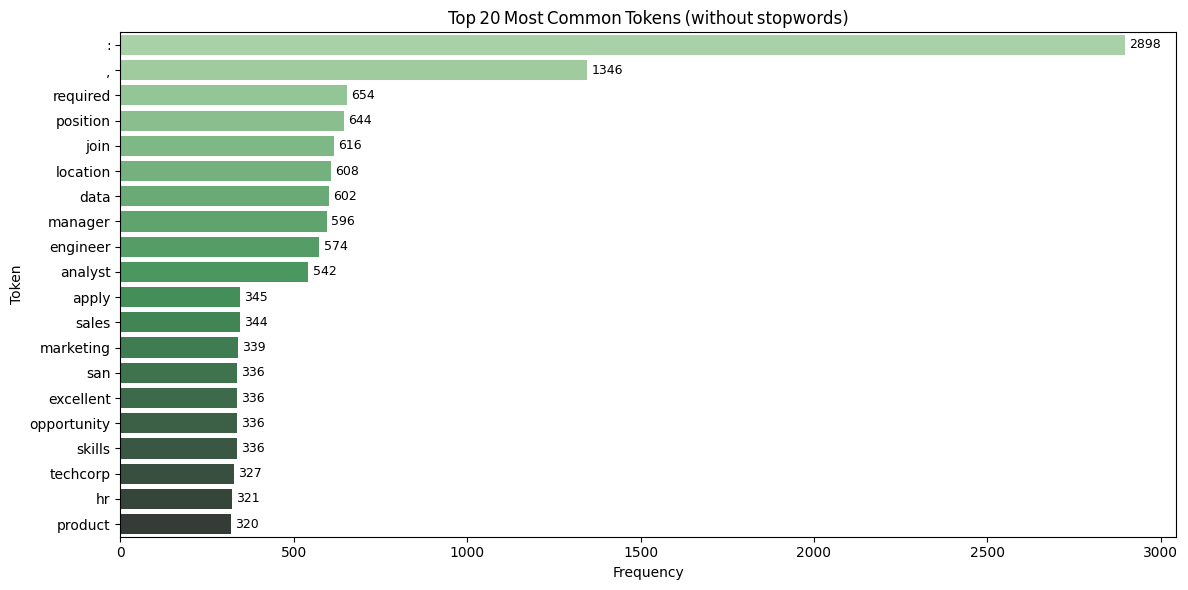

In [48]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Plot without stopwords
token_freq_no_stop = Counter(all_tokens_no_stop)
top_tokens_no_stop = token_freq_no_stop.most_common(20)
words, counts = zip(*top_tokens_no_stop)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=list(counts), y=list(words), hue=list(words),
                 palette='Greens_d', legend=False)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=9, padding=3, color='black')

plt.xlabel('Frequency')
plt.ylabel('Token')
plt.title('Top 20 Most Common Tokens (without stopwords)')
plt.tight_layout()
plt.show()


The token‑frequency analysis highlights the compact and highly regular nature of the dataset.
Out of 39,832 total tokens, only 134 unique words appear, dropping to 123 once stopwords are removed clear evidence of a templated, synthetic corpus with limited lexical diversity.

In both charts, punctuation marks such as “:” and “,” dominate, confirming their systematic use in patternized sentence structures.

When stopwords are excluded, domain‑specific words like “required”, “position”, “manager”, “engineer”, “data”, and “apply” rise to the top — precisely matching the vocabulary expected in job‑related templates.

#### **Word Cloud Visualization**



The overall word cloud provides a high-level overview of the most frequent tokens across the entire dataset, combining all entity types into a single representation.


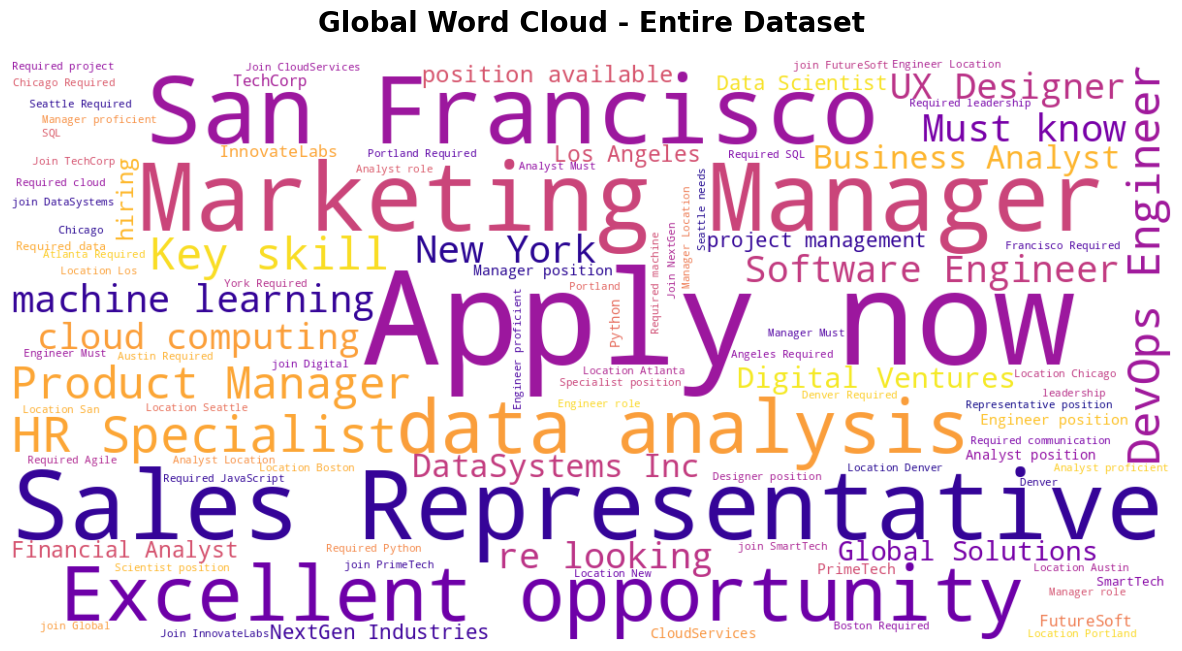

In [49]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_text = " ".join([" ".join(sample['tokens']) for sample in train_cleaned])

wordcloud_global = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='plasma',
    max_words=100,
    contour_width=1,
    contour_color='steelblue'
).generate(all_text)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud_global, interpolation='bilinear')
plt.axis('off')
plt.title('Global Word Cloud - Entire Dataset', fontsize=20, fontweight='bold', pad=20)
plt.show()

The global word cloud perfectly reinforces every insight gathered from the preceding EDA.

The visualization makes the dataset’s synthetic and template‑driven character instantly recognizable: dominant phrases such as “Apply now,” “Excellent opportunity,” “Sales Representative,” “Marketing Manager,” “San Francisco,” and “data analysis” occupy central positions, proving how strongly the corpus revolves around a limited set of recurring patterns.

Entity categories are all clearly visible job titles, companies, locations, and skills reflecting the 100 % entity coverage achieved during the cleaning and re‑annotation phase. Their balanced presence confirms that each text instance now contains one of every entity type.

The heavy repetition of imperative expressions (“Apply,” “Join,” “Required”) and company or location names demonstrates both the reduced lexical diversity (only 134 unique tokens) and the repetitive template structure already shown by the token‑frequency histograms and short sequence‑length analysis.

Overall, this word cloud serves as an intuitive visual summary of the dataset’s architecture — concise, controlled, and highly regular — providing a final qualitative proof of the successful preprocessing and the dataset’s internal consistency.


## **Linguistic Information**

### **POS Tagging Analysis**


To better understand the syntactic structure of our recruitment corpus, we process the cleaned text through spaCy's linguistic pipeline. Analyzing the Part-of-Speech (POS) distribution helps us confirm that the grammatical context surrounding our entities is consistent with natural professional language.

In [52]:
import pandas as pd
from collections import Counter

train_sentences_clean = [' '.join(r['tokens']) for r in train_cleaned]
docs = list(nlp.pipe(train_sentences_clean, batch_size=100))

pos_tags = []
for doc in docs:
    for token in doc:
        if not token.is_punct and not token.is_space:
            pos_tags.append(token.pos_)

pos_freq = Counter(pos_tags)
total_tags = len(pos_tags)
df_pos = pd.DataFrame(pos_freq.items(), columns=['POS_Tag', 'Count'])
df_pos['Percentage (%)'] = (df_pos['Count'] / total_tags * 100).round(1)
df_pos = df_pos.sort_values(by='Count', ascending=False).reset_index(drop=True)

print(f"POS Tag Distribution (Total tags: {total_tags:,}):\n")
display(df_pos)

POS Tag Distribution (Total tags: 34,958):



,POS_Tag,Count,Percentage (%)
0,PROPN,15198,43.5
1,NOUN,7581,21.7
2,ADP,3982,11.4
3,VERB,3917,11.2
4,AUX,1249,3.6
5,ADJ,1124,3.2
6,DET,912,2.6
7,ADV,354,1.0
8,PRON,307,0.9
9,PART,307,0.9


In [51]:
train_sentences_clean = [' '.join(r['tokens']) for r in train_cleaned]
docs = list(nlp.pipe(train_sentences_clean, batch_size=100))

pos_tags = []
for doc in docs:
    for token in doc:
        if not token.is_punct and not token.is_space:
            pos_tags.append(token.pos_)

pos_freq = Counter(pos_tags)

print("POS Tag Distribution:")
print("=" * 40)
for pos, count in pos_freq.most_common():
    print(f"  {pos:{6}}: {count:5d} ({100*count/len(pos_tags):.1f}%)")

POS Tag Distribution:
  PROPN : 15198 (43.5%)
  NOUN  :  7581 (21.7%)
  ADP   :  3982 (11.4%)
  VERB  :  3917 (11.2%)
  AUX   :  1249 (3.6%)
  ADJ   :  1124 (3.2%)
  DET   :   912 (2.6%)
  ADV   :   354 (1.0%)
  PRON  :   307 (0.9%)
  PART  :   307 (0.9%)
  SCONJ :    27 (0.1%)


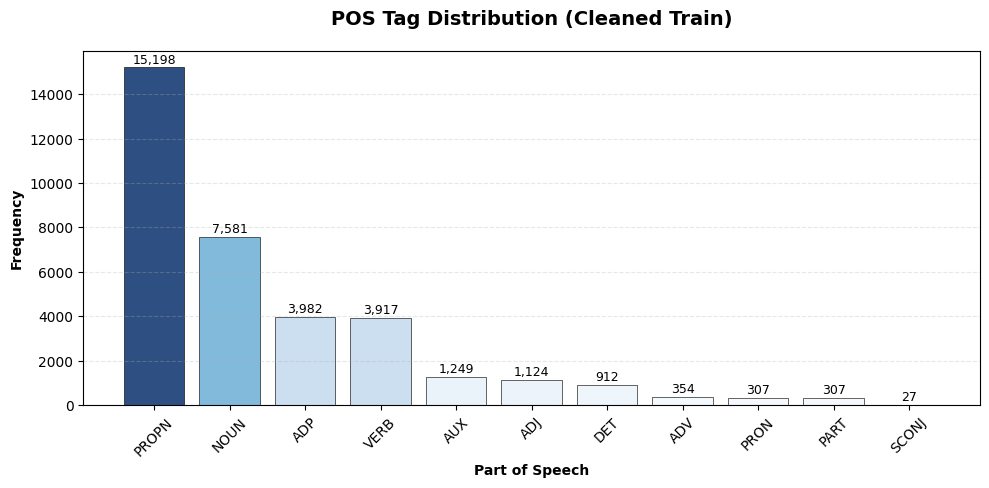

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))
pos_sorted = pos_freq.most_common()
names = [p[0] for p in pos_sorted]
counts = [p[1] for p in pos_sorted]

cmap = plt.get_cmap('Blues')
norm = mcolors.Normalize(vmin=min(counts), vmax=max(counts))
colors = [cmap(norm(value)) for value in counts]
ax.bar(names, counts, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)

for i, v in enumerate(counts):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=9)
ax.set_xlabel('Part of Speech', fontweight='bold')
ax.set_ylabel('Frequency', fontweight='bold')
ax.set_title('POS Tag Distribution (Cleaned Train)', fontweight='bold', fontsize=14, y=1.05)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


The bar and pie charts above visualize the global Part-of-Speech (POS) distribution across our cleaned training set. The results reveal a distinct linguistic fingerprint, highly characteristic of a specialized Named Entity Recognition (NER) corpus rather than natural conversational prose.


The absolute dominance of Proper Nouns **`PROPN` at 43.6%**, represented by the darkest bar and the exploded pie slice completely dwarfs all other categories. This confirms that the synthetic generation heavily favors specific entity names (companies, locations, and software technologies) over descriptive text.

Standard **`NOUN`s (21.6%)** represent the second-largest group, covering general job roles (e.g., "Engineer", "Manager") and soft skills (e.g., "management", "communication"). Together, Nouns and Proper Nouns make up over 65% of the entire dataset.

Adpositions **`ADP` at 11.4%**, (e.g., "in", "at") and Verbs **`VERB` at 11.2%**, (e.g., "hiring", "seeking") act as the necessary structural glue connecting the entities (e.g., *[VERB] hiring at [COMPANY] in [LOCATION]*).

The "long tail" of the distribution is extremely flat. Grammatical categories that typically populate natural language—like Pronouns (`PRON`), Adverbs (`ADV`), and Conjunctions (`SCONJ`)—are nearly non-existent here (less than 5% combined).

#### **POS Distribution by Entity Type**

In [ ]:
entity_pos = {'JOBTITLE': [], 'COMPANY': [], 'LOCATION': [], 'SKILL': [], 'O': []}

for doc, sample in zip(docs, train_cleaned):
    for token, label in zip(doc, sample['labels']):
        if token.is_punct or token.is_space:
            continue
        etype = 'O' if label == 'O' else label.split('-')[1]
        entity_pos[etype].append(token.pos_)

print("POS Distribution by Entity Type:")
print("=" * 60)
for etype in ['JOBTITLE', 'COMPANY', 'LOCATION', 'SKILL', 'O']:
    pos_dist = Counter(entity_pos[etype])
    total = len(entity_pos[etype])
    print(f'\n  {etype}:')
    for pos, count in pos_dist.most_common(5):
        print(f'    {pos:{6}}: {count:5d} ({100*count/total:.1f}%)')

POS Distribution by Entity Type:

  JOBTITLE:
    PROPN :  5274 (83.9%)
    NOUN  :   841 (13.4%)
    ADJ   :   169 (2.7%)

  COMPANY:
    PROPN :  4304 (99.4%)
    NOUN  :    19 (0.4%)
    ADV   :     9 (0.2%)

  LOCATION:
    PROPN :  4078 (100.0%)

  SKILL:
    NOUN  :  2946 (67.3%)
    PROPN :  1367 (31.2%)
    VERB  :    65 (1.5%)

  O:
    ADP   :  3982 (25.1%)
    VERB  :  3852 (24.2%)
    NOUN  :  3775 (23.8%)
    AUX   :  1249 (7.9%)
    ADJ   :   955 (6.0%)



By grouping the Part-of-Speech tags by their corresponding Entity Labels, we uncover the specific grammatical "fingerprints" of our classes. This breakdown provides crucial insights into how our models might learn to differentiate them:

**`LOCATION`** is strictly 100% `PROPN`, and **`COMPANY`** is nearly identical at 99.4%. For a Named Entity Recognition system, this is an incredibly strong signal: if a token is a Location or a Company, it is almost guaranteed to be grammatically structured as a Proper Noun.

Unlike companies, **`SKILL`** entities represent concepts, tools, or practices. This is perfectly reflected in their composition: mostly common Nouns (`NOUN` at 67.3%, e.g., "management", "analysis") and some Proper Nouns (`PROPN` at 31.2%, e.g., "Python", "SQL").

**`JOBTITLE`** entities show a varied grammatical structure consisting of Proper Nouns (83.9%), regular Nouns (13.4%), and Adjectives (2.7%, likely for seniority modifiers like "Senior" or descriptive terms like "Financial").

The background text **`O` class** is completely different from the entities. It is dominated by Adpositions (`ADP`, 25.1%) and Verbs (`VERB`, 24.2%). This confirms that the non-entity text serves purely as the syntactic "glue" that connects the entities together (e.g., prepositions like "in" or "at", and action verbs like "hiring" or "seeking").


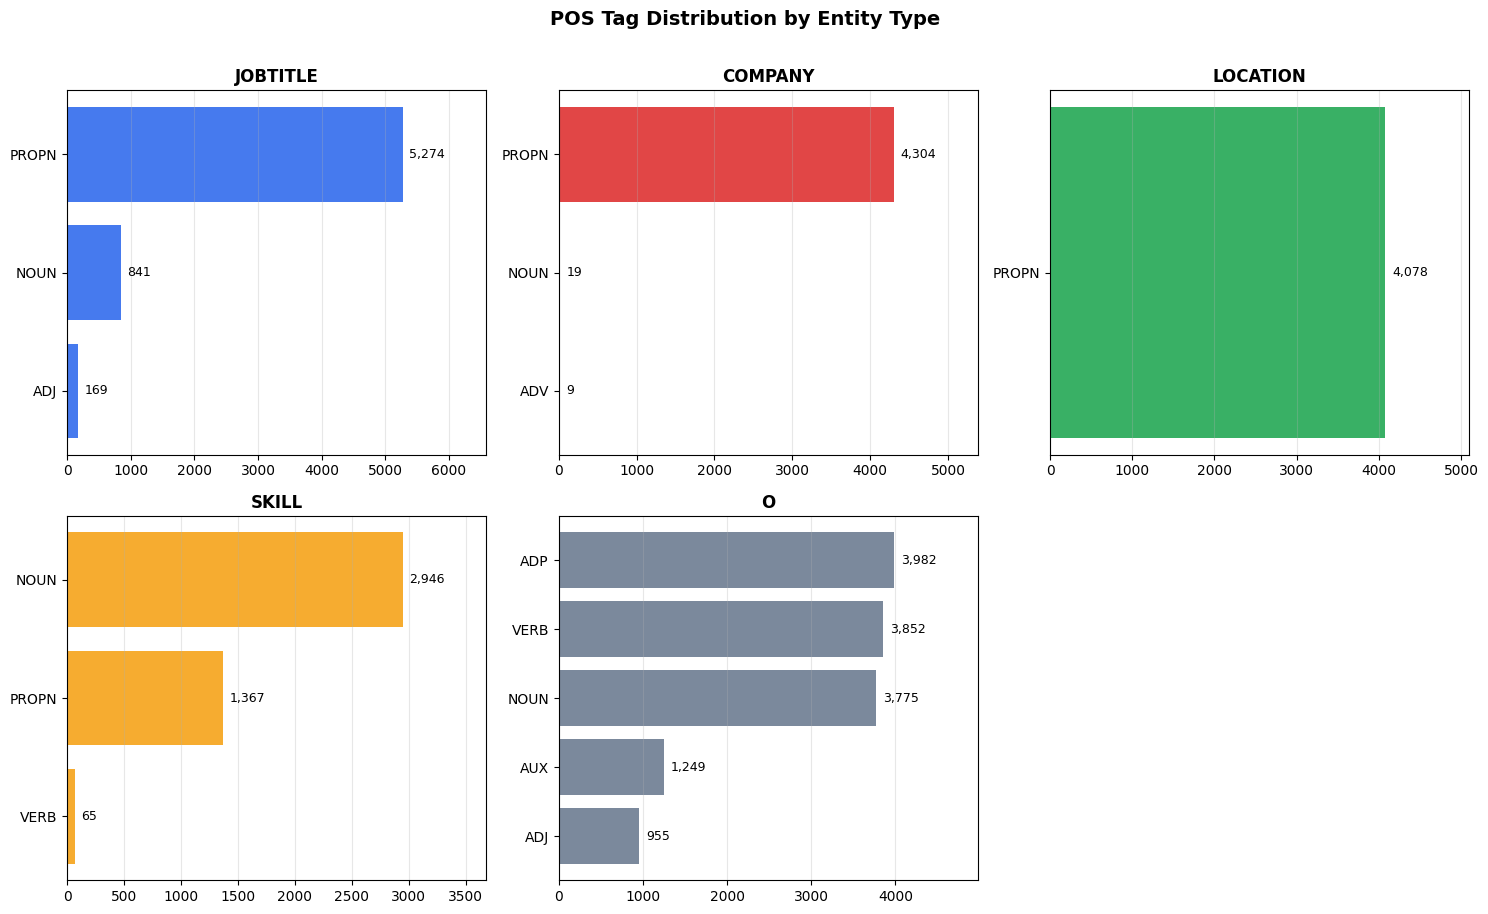

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes_flat = axes.flat

palette_etype = {'JOBTITLE': '#2563eb', 'COMPANY': '#dc2626',
                 'LOCATION': '#16a34a', 'SKILL': '#f59e0b', 'O': '#64748b'}

for ax, etype in zip(axes_flat, ['JOBTITLE', 'COMPANY', 'LOCATION', 'SKILL', 'O']):
    pos_dist = Counter(entity_pos[etype])
    top = pos_dist.most_common(5)
    names = [p[0] for p in top][::-1]
    counts = [p[1] for p in top][::-1]
    bars = ax.barh(names, counts, color=palette_etype[etype], alpha=0.85)
    for i, v in enumerate(counts):
        ax.text(v + max(counts)*0.02, i, f'{v:,}', va='center', fontsize=9)
    ax.set_title(etype, fontweight='bold', fontsize=12)
    ax.set_xlim(0, max(counts) * 1.25)
    ax.grid(axis='x', alpha=0.3)

axes_flat[5].set_visible(False)

plt.suptitle('POS Tag Distribution by Entity Type', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


This grid of horizontal bar charts visually synthesizes our findings regarding the grammatical composition of each label. The visual contrast between the subplots is striking and highly informative for our modeling strategy:

`COMPANY` (red) and `LOCATION` (green) are visibly monolithic. Their charts show a single, massive spike for Proper Nouns (`PROPN`), confirming they are grammatically homogeneous.

`JOBTITLE` (blue) and `SKILL` (orange) exhibit a clear "staircase" pattern. While they have a dominant POS tag, they also rely significantly on secondary tags (like regular `NOUN` and `ADJ`). This multi-tag distribution reflects the complex, multi-word nature of roles and technical competencies.

 The background class `O` (gray) stands in stark contrast to all entity types. Its balanced distribution across Adpositions (`ADP`), Verbs (`VERB`), and Nouns (`NOUN`) visualizes its role as the connective tissue that builds the sentence structure around our target entities.


Building on the general POS distribution analysis, we conducted a more granular investigation to examine the few remaining inconsistencies within specific entity types.
While the overall patterns were clear we wanted to understand why small fractions of unexpected tags appeared by isolating these outliers.

**Find JOBTITLE tokens tagged as ADJ**

In [ ]:
print("JOBTITLE tokens with POS = ADJ:")
print("=" * 50)

adj_jobtitles = Counter()
for doc, sample in zip(docs, train_cleaned):
    for token, label in zip(doc, sample['labels']):
        if label in ['B-JOBTITLE', 'I-JOBTITLE'] and token.pos_ == 'ADJ':
            adj_jobtitles[token.text] += 1

for word, count in adj_jobtitles.most_common():
    print(f'  "{word}": {count} times')

JOBTITLE tokens with POS = ADJ:
  "Specialist": 139 times
  "Financial": 30 times



In our previous POS distribution analysis, we noted a small proportion (2.7%) of ADJ tags within JOBTITLE entities. By isolating these tokens, we can better understand spaCy's behavior on domain‑specific terms.

• “Financial” (30 occurrences): grammatically correct — in “Financial Analyst”, it functions as an adjective modifying the noun Analyst.

• “Specialist” (139 occurrences): an interesting edge case — in titles like “HR Specialist”, this word is semantically a noun, yet spaCy often misclassifies it as an adjective because of the dataset’s telegraphic, title‑case style.

This demonstrates why off‑the‑shelf POS models are insufficient for specialized entity extraction tasks.

**find COMPANY tokens tagged as ADV & NOUN**

In [ ]:
print("\nCOMPANY tokens with POS = ADV:")
adv_company = Counter()
noun_company = Counter()
for doc, sample in zip(docs, train_cleaned):
    for token, label in zip(doc, sample['labels']):
        if label in ['B-COMPANY', 'I-COMPANY']:
            if token.pos_ == 'ADV':
                adv_company[token.text] += 1
            elif token.pos_ == 'NOUN':
                noun_company[token.text] += 1

for word, count in adv_company.most_common():
    print(f'  "{word}": {count} times')

print("\nCOMPANY tokens with POS = NOUN:")
for word, count in noun_company.most_common():
    print(f'  "{word}": {count} times')


COMPANY tokens with POS = ADV:
  "FutureSoft": 9 times

COMPANY tokens with POS = NOUN:
  "CloudServices": 19 times



Following the JOBTITLE analysis, the same inspection applied to COMPANY entities reveals a few rare tagging anomalies.

• “CloudServices” → NOUN (19 times): the CamelCase structure confuses spaCy’s general model; it treats Services as a plural noun instead of recognizing the entire compound as a single Proper Noun.

• “FutureSoft” → ADV (9 times): an example of misclassification on synthetic brand names — lacking semantic grounding, spaCy assigns an implausible Adverb tag.

These errors highlight how non‑standard capitalization and concatenated naming patterns can distort linguistic models trained on natural text.

**Find SKILL tokens tagged as VERB**

In [ ]:
from collections import Counter

print("SKILL tokens with POS = VERB:")
print("=" * 50)

verb_skills = Counter()
for doc, sample in zip(docs, train_cleaned):
    for token, label in zip(doc, sample['labels']):
        if label in ['B-SKILL', 'I-SKILL'] and token.pos_ == 'VERB':
            verb_skills[token.text] += 1

for word, count in verb_skills.most_common():
    print(f'  "{word}": {count} times')

SKILL tokens with POS = VERB:
  "cloud": 33 times
  "learning": 32 times


Extending the POS analysis to SKILL entities, we found a small proportion (1.5%) tagged as VERB.

• “cloud” (33 times): in phrases like “cloud computing”, spaCy sometimes tags cloud as a verb, reflecting the challenge of interpreting technical terms in short, title‑style contexts.

• “learning” (32 times): correctly identified as a gerund verb, yet in “machine learning” it semantically functions as a noun.

As with JOBTITLEs, these findings confirm that standard POS models cannot fully capture the specialized grammar of technical skill expressions.

### **Lemma Analysis**

Is the process of reducing words to their base or canonical form, called lemma. This technique is widely used in natural language processing (NLP) to normalize text, allowing different word forms to be treated as a single entity. Lemmatization helps improve text analysis tasks such as token counting, information retrieval, and sentiment analysis, because it reduces redundancy and captures the core meaning of words.

In [53]:
all_tokens_text = []
all_lemmas = []

for doc in docs:
    for token in doc:
        if not token.is_punct and not token.is_space:
            all_tokens_text.append(token.text.lower())
            all_lemmas.append(token.lemma_.lower())

print(f"Unique tokens: {len(set(all_tokens_text))}")
print(f"Unique lemmas: {len(set(all_lemmas))}")
print(f"Vocabulary reduction: {(1 - len(set(all_lemmas))/len(set(all_tokens_text)))*100:.1f}%")

print(f"\n{'Token':{20}} {'Lemma':{20}} {'Changed?'}")
print("-" * 50)
seen = set()
for doc in docs:
    for token in doc:
        if not token.is_punct and not token.is_space:
            if token.text != token.lemma_ and token.text not in seen:
                print(f"{token.text:{20}} {token.lemma_:{20}} YES")
                seen.add(token.text)

Unique tokens: 92
Unique lemmas: 93
Vocabulary reduction: -1.1%

Token                Lemma                Changed?
--------------------------------------------------
is                   be                   YES
hiring               hire                 YES
Apply                apply                YES
Required             require              YES
Excellent            excellent            YES
Analyst              analyst              YES
Skills               skill                YES
needs                need                 YES
We                   we                   YES
're                  be                   YES
looking              look                 YES
HR                   hr                   YES
Specialist           specialist           YES
Seeking              seek                 YES
located              locate               YES
Must                 must                 YES
data                 datum                YES
skills               skill                YES
Join 


Applying lemmatization to our corpus yielded a highly unusual and insightful result: a **negative vocabulary reduction (-1.2%)**. Instead of shrinking the vocabulary, the number of unique lemmas (93) slightly exceeded the number of unique tokens (92).

This phenomenon reveals three aspects of our dataset:

1. **The Ultimate Synthetic Proof:** Across more than 3,000 sentences, there are only **92 unique tokens** in total. This exceptionally tiny, closed-world vocabulary is the definitive "smoking gun" that the entire dataset was programmatically generated using a very rigid set of templates.
2. **Context-Aware Lemmatization Splitting:** Why did the count increase? Because spaCy relies on Part-of-Speech tags to lemmatize. If a word like "learning" acts as a verb in one template but as a noun in another (e.g., "Machine learning"), spaCy generates two distinct lemmas (e.g., "learn" and "learning") for the same original token. This 1-to-2 mapping artificially inflates the lemma count.
3. **Valid Normalizations:** Despite the anomaly, the examples show that the engine correctly normalized structural verbs (`"is"`, `"'re"` $\rightarrow$ `"be"`; `"hiring"`, `"seeking"` $\rightarrow$ `"hire"`, `"seek"`) and plural nouns (`"Requirements"`, `"skills"` $\rightarrow$ `"requirement"`, `"skill"`). Interestingly, "Data" was properly traced back to its Latin singular root `"datum"`.


In [ ]:
print("LEMMATIZATION IMPACT ON ENTITIES:")
print("=" * 60)

entity_lemma_changes = {'JOBTITLE': [], 'COMPANY': [], 'LOCATION': [], 'SKILL': [], 'O': []}

for doc, sample in zip(docs, train_cleaned):
    for token, label in zip(doc, sample['labels']):
        if token.is_punct or token.is_space:
            continue
        etype = 'O' if label == 'O' else label.split('-')[1]
        if token.text.lower() != token.lemma_.lower():
            entity_lemma_changes[etype].append((token.text, token.lemma_))

for etype in ['JOBTITLE', 'COMPANY', 'LOCATION', 'SKILL', 'O']:
    changes = Counter(entity_lemma_changes[etype])
    total_tokens = len(entity_pos[etype])
    changed = len(entity_lemma_changes[etype])
    print(f'\n  {etype}: {changed}/{total_tokens} tokens changed ({100*changed/total_tokens:.1f}%)')
    if changes:
        for (orig, lemma), count in changes.most_common(5):
            print(f'    "{orig}" → "{lemma}" ({count} times)')

LEMMATIZATION IMPACT ON ENTITIES:

  JOBTITLE: 197/6284 tokens changed (3.1%)
    "Sales" → "sale" (134 times)
    "Data" → "datum" (63 times)

  COMPANY: 19/4332 tokens changed (0.4%)
    "CloudServices" → "cloudservice" (19 times)

  LOCATION: 0/4078 tokens changed (0.0%)

  SKILL: 336/4378 tokens changed (7.7%)
    "data" → "datum" (304 times)
    "learning" → "learn" (32 times)

  O: 4023/15886 tokens changed (25.3%)
    "Required" → "require" (654 times)
    "Skills" → "skill" (336 times)
    "needs" → "need" (317 times)
    "seeks" → "seek" (314 times)
    "'re" → "be" (307 times)


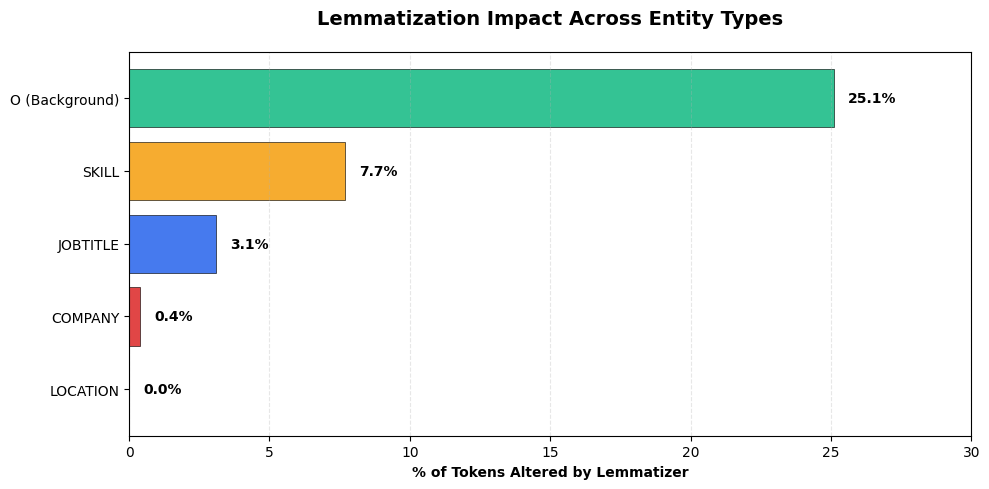

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

entity_classes = ['LOCATION', 'COMPANY', 'JOBTITLE', 'SKILL', 'O (Background)']
changed_percentages = [0.0, 0.4, 3.1, 7.7, 25.1]
colors = ['#16a34a', '#dc2626', '#2563eb', '#f59e0b', '#10b981']
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(entity_classes, changed_percentages, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
for i, v in enumerate(changed_percentages):
    ax.text(v + 0.5, i, f'{v}%', va='center', fontweight='bold', fontsize=10)
ax.set_xlabel('% of Tokens Altered by Lemmatizer', fontweight='bold')
ax.set_title('Lemmatization Impact Across Entity Types', fontweight='bold', fontsize=14, y=1.05)
ax.set_xlim(0, 30)
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


By breaking down the lemmatization changes by entity class, we can observe exactly how text normalization interacts with our domain-specific vocabulary. This analysis yields a definitive answer on whether to lemmatize our training data:

1. **Unaltered Proper Nouns (`LOCATION`):** The `LOCATION` class experienced a **0.0% change rate**. Proper nouns representing cities simply do not have morphological variations in English.
2. **Destructive Normalization (`COMPANY` & `JOBTITLE`):** While the change rates are low (0.4% and 3.1%), the lemmatizer actually *damages* the semantic integrity of these entities. Changing the brand name `"CloudServices"` to `"cloudservice"` destroys its CamelCase formatting. Similarly, `"Sales"` is the correct departmental terminology for a Job Title, whereas the lemma `"sale"` refers to a transaction.
3. **Concept Normalization (`SKILL`):** Skills saw a 7.7% change rate, mostly mapping the Latin plural `"data"` to `"datum"`, and the gerund `"learning"` to `"learn"`. While grammatically correct, "machine learning" is a fixed industry term; breaking it down to "machine learn" removes its recognized form.
4. **Structural Standardization (`O`):** As expected, the background text (`O` class) saw a massive **25.1% change rate**. The lemmatizer successfully standardized action verbs (`"needs"`, `"seeks"`, `"'re"`) and plural section headers (`"Required"`, `"Skills"`).

**Final Preprocessing Decision:** This deep dive completely rules out lemmatization for our Token Classification (NER) pipeline. While normalizing verbs in the background text (`O`) is logically sound, altering the tokens inside our entities (`B-`, `I-` tags) destroys the specific morphological and capitalized cues that define brand names, job titles, and specific technologies. We will proceed with the raw, unlemmatized tokens to preserve these critical entity features.

### **Dependency Parsing**

Dependency parsing analyzes the grammatical structure of a sentence by showing relationships between words, identifying which words modify or depend on others. It’s used in NLP to understand syntax and meaning.

In [ ]:
dep_tags = []
entity_dep = {'JOBTITLE': [], 'COMPANY': [], 'LOCATION': [], 'SKILL': [], 'O': []}

for doc, sample in zip(docs, train_cleaned):
    for token, label in zip(doc, sample['labels']):
        if token.is_punct or token.is_space:
            continue
        dep_tags.append(token.dep_)
        etype = 'O' if label == 'O' else label.split('-')[1]
        entity_dep[etype].append(token.dep_)

dep_freq = Counter(dep_tags)
print("Dependency Tag Distribution:")
print("=" * 45)
for dep, count in dep_freq.items():
    print(f"  {dep:{12}}: {count:5d} ({100*count/len(dep_tags):.1f}%) — {spacy.explain(dep)}")

print("\n\nDependency Distribution by Entity Type:")
print("=" * 55)
for etype in ['JOBTITLE', 'COMPANY', 'LOCATION', 'SKILL', 'O']:
    dep_dist = Counter(entity_dep[etype])
    total = len(entity_dep[etype])
    print(f'\n  {etype}:')
    for dep, count in dep_dist.most_common(5):
        print(f'    {dep:{12}}: {count:5d} ({100*count/total:.1f}%) — {spacy.explain(dep)}')

Dependency Tag Distribution:
  compound    :  8269 (23.7%) — compound
  nsubj       :  1660 (4.7%) — nominal subject
  aux         :  1556 (4.5%) — auxiliary
  ROOT        :  6026 (17.2%) — root
  det         :   912 (2.6%) — determiner
  dobj        :  2712 (7.8%) — direct object
  prep        :  3982 (11.4%) — prepositional modifier
  pobj        :  3922 (11.2%) — object of preposition
  advmod      :   351 (1.0%) — adverbial modifier
  appos       :  2965 (8.5%) — appositional modifier
  amod        :  1075 (3.1%) — adjectival modifier
  acl         :   528 (1.5%) — clausal modifier of noun (adjectival clause)
  mark        :    27 (0.1%) — marker
  advcl       :   247 (0.7%) — adverbial clause modifier
  csubj       :    21 (0.1%) — clausal subject
  dep         :   295 (0.8%) — unclassified dependent
  npadvmod    :   214 (0.6%) — noun phrase as adverbial modifier
  relcl       :    34 (0.1%) — relative clause modifier
  csubjpass   :     3 (0.0%) — clausal subject (passive)
  con

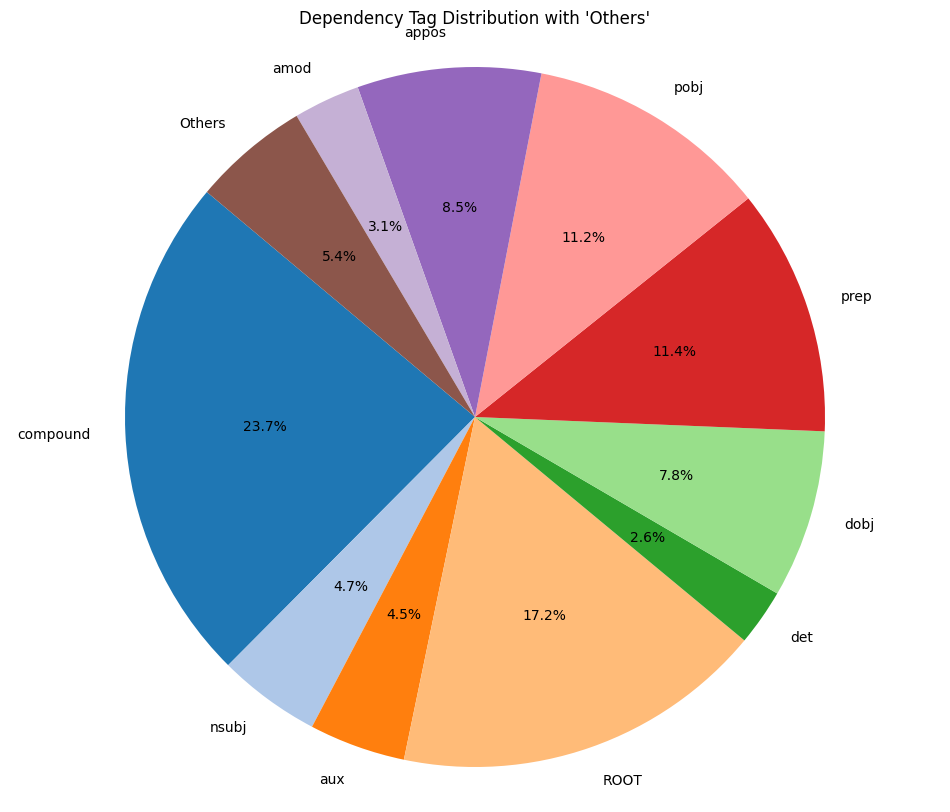

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

main_tags = ["compound", "ROOT", "prep", "pobj", "appos", "dobj", "nsubj", "aux", "amod", "det"]

counts_main = []
counts_other = 0
labels_main = []

for dep, count in dep_freq.items():
    if dep in main_tags:
        labels_main.append(dep)
        counts_main.append(count)
    else:
        counts_other += count

labels_main.append("Others")
counts_main.append(counts_other)

colors = plt.cm.tab20.colors * ((len(labels_main) // 20) + 1)

plt.figure(figsize=(12, 10))
plt.pie(counts_main, labels=labels_main, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title("Dependency Tag Distribution with 'Others'")
plt.axis('equal')
plt.show()

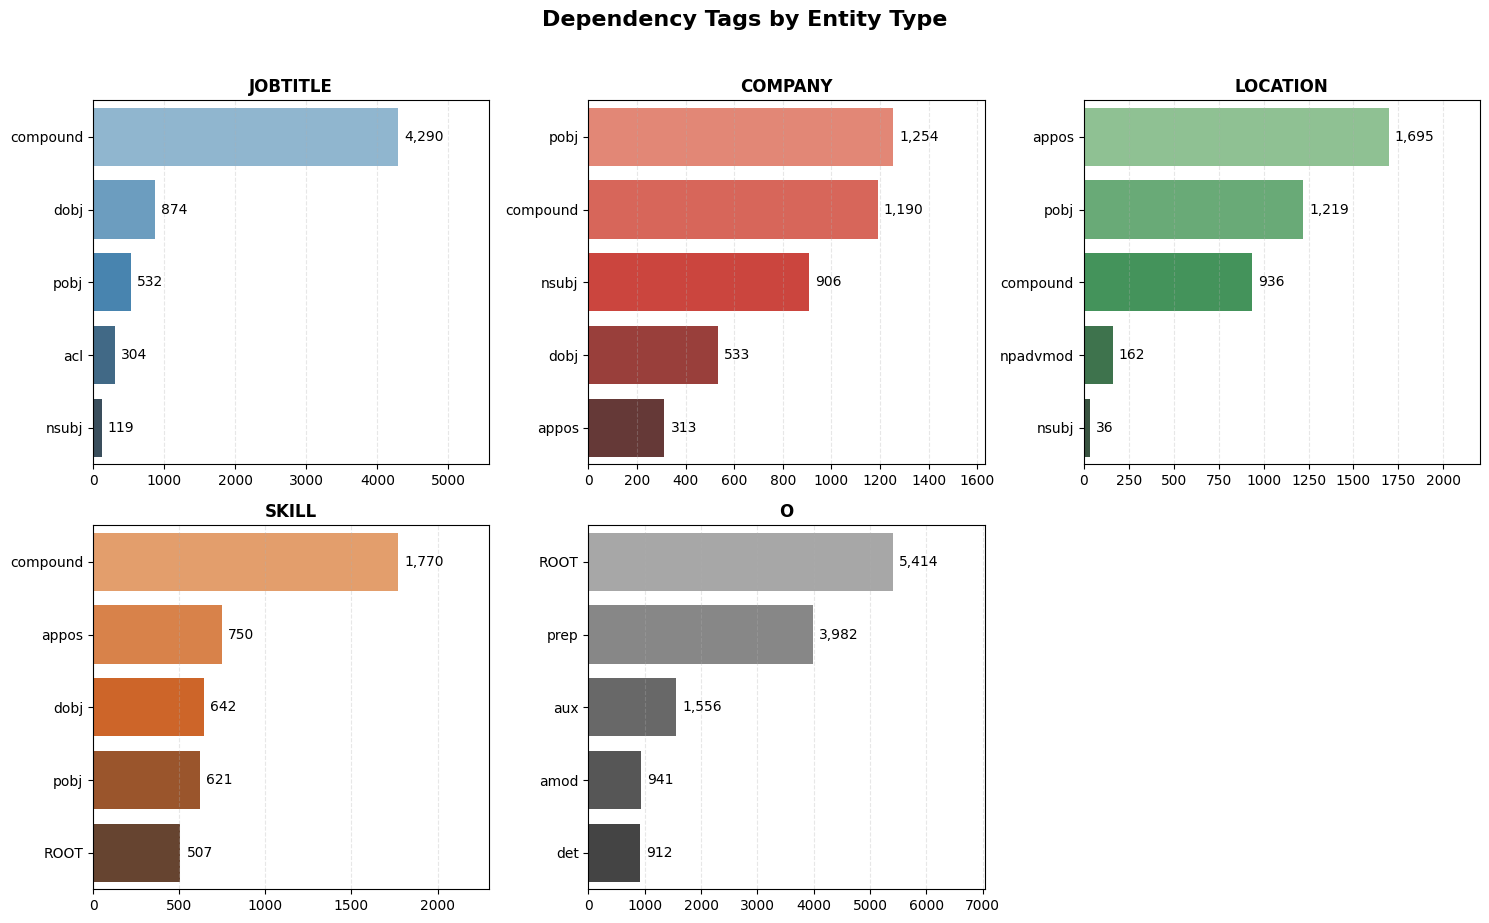

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes_flat = axes.flat

palettes = {
    'JOBTITLE': 'Blues_d',
    'COMPANY': 'Reds_d',
    'LOCATION': 'Greens_d',
    'SKILL': 'Oranges_d',
    'O': 'Greys_d'
}

for ax, etype in zip(axes_flat, ['JOBTITLE', 'COMPANY', 'LOCATION', 'SKILL', 'O']):
    dep_dist = Counter(entity_dep[etype])
    top = dep_dist.most_common(5)
    names = [p[0] for p in top]
    counts = [p[1] for p in top]

    sns.barplot(x=counts, y=names, hue=names, palette=palettes[etype], legend=False, ax=ax)
    for i, v in enumerate(counts):
        ax.text(v + max(counts)*0.02, i, f'{v:,}', va='center', fontsize=10)

    ax.set_title(etype, fontweight='bold', fontsize=12)
    ax.set_xlim(0, max(counts) * 1.3)
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.grid(axis='x', alpha=0.3, linestyle='--')

axes_flat[5].set_visible(False)

plt.suptitle('Dependency Tags by Entity Type', fontweight='bold', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Dependency Parsing reveals how words *interact*. This analysis uncovers the structural templates that define our dataset:

1. **The "Compound" Dominance:** The most frequent tag is `compound` (23.7%). This is especially visible in `JOBTITLE` (68.3%) and `SKILL` (40.4%). It confirms that our entities are mostly multi-word expressions (e.g., in "Data Scientist", "Data" is a compound modifier of "Scientist").
2. **Location as an Apposition:** `LOCATION` has a unique signature: its most frequent tag is `appos` (41.6%, Appositional Modifier). This reflects the common template: *"hiring in [City], [State]"* or *"[Company] in [Location]"*, where the location acts as a supplementary information block.
3. **Company as the Subject/Object:** `COMPANY` entities frequently act as the `nsubj` (Nominal Subject, 20.9%) or `pobj` (Object of Preposition, 28.3%). This maps to structures like: *"[Company] is hiring"* or *"available at [Company]"*.
4. **The Background 'O' as the Anchor:** The `O` class contains the `ROOT` of the sentences (33.9%), usually the main verb like "hiring" or "seeking", and the `prep` (Prepositions, 25.1%) that link the entities together.


Try with some random examples

In [ ]:
from spacy import displacy

for idx in range(5):
    print(f"\n{train_cleaned[idx]['id']}: {docs[idx].text}\n")
    displacy.render(docs[idx], style='dep', jupyter=True,
                    options={'distance': 90, 'compact': True})


job_00000: NextGen Industries is hiring a DevOps Engineer in San Francisco with SQL experience .




job_00001: Apply now : Software Engineer position , DataSystems Inc , Atlanta . Required : leadership .




job_00002: Excellent opportunity : Business Analyst at NextGen Industries , Seattle . Skills : Python .




job_00003: NextGen Industries in Austin needs Product Manager proficient in Agile .




job_00004: We 're looking for a Data Scientist with project management to join Digital Ventures in Chicago .




We use `displacy` to render the dependency trees of sample job postings. These visualizations act as a graphical summary of our linguistic findings:

1. **Entity Internal Structure:** The horizontal "compound" arcs within titles like *DevOps Engineer* or *NextGen Industries* show how tokens cluster together to form a single semantic unit.
2. **Syntactic Anchors:** We can visually trace how prepositions (like "in" or "at") act as anchors that point directly to `LOCATION` or `COMPANY` entities, providing the model with clear spatial and organizational context.
3. **Template Regularity:** By comparing multiple samples, the extreme regularity of these trees becomes evident. The sentences follow near-identical branching patterns, which explains the "spiky" distribution we observed in our earlier length and POS analyses.


### **Topic Modeling (NMF)**


Topic modeling techniques like LDA (Latent Dirichlet Allocation) and NMF (Non-Negative Matrix Factorization) are commonly used in text mining to discover hidden thematic structures in document collections. We investigated whether these techniques could provide useful insights for our job posting NER dataset.

**Why Topic Modeling Is Not Applicable to Our Dataset**

After applying NMF with TF-IDF vectorization, we found that **topic modeling does not yield meaningful results** for this dataset. The evidence is twofold:

**1. No optimal number of topics exists.** The reconstruction error decreases linearly as we increase the number of topics (see plot below), with no "elbow point" indicating a natural clustering. This means the data does not contain distinct thematic groups — unlike a news corpus where articles naturally cluster into politics, sports, science, etc.

**2. Discovered topics heavily overlap.** The top words in each topic are largely shared across all topics (e.g., "engineer", "data", "position" appear in multiple topics). This is because all 3,200 sentences describe the same thing, a job posting, using a shared vocabulary of only 78 features after TF-IDF filtering.

**Root Cause**

The dataset was generated from **sentence templates** with a **closed vocabulary** of 136 unique tokens. The variation across sentences is not thematic (different subjects) but **structural** (different syntactic patterns) and **entity-based** (different combinations of company names, job titles, locations, and skills). Topic modeling is designed to capture thematic variation, not structural or entity-level variation.

**Conclusion**

This finding reinforces that our task is fundamentally a **Named Entity Recognition** problem, not a topic classification problem. All sentences share the same theme (job postings) and the same vocabulary, so the only meaningful variation is **which tokens are entities and which are not**.

## Exporting Results for the Dashboard


In [ ]:
import shutil
import os

RESULTS_PATH = '/content/drive/MyDrive/RESULTS'

os.makedirs(RESULTS_PATH, exist_ok=True)

shutil.copy('train_cleaned.jsonl', os.path.join(RESULTS_PATH, 'train_cleaned.jsonl'))
shutil.copy('test_retokenized.jsonl', os.path.join(RESULTS_PATH, 'test_retokenized.jsonl'))

print(f"File salvati con successo in: {RESULTS_PATH}")

File salvati con successo in: /content/drive/MyDrive/RESULTS
